## Model Loading

In [ ]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05/42/best.pt"

#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05/42/best_joint.pt"
#ckpt_path = joint_ckpt_pretrain_path
'''
    ckpt_path , joint_ckpt_pretrain_path 위 버전이 bary 있고 z_scoring한 버전. 0.5 버전임. collapse는 없지만 sample 차원에서는 entropy 높음.
'''
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05_2/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05_2/42/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03/42/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03_NOBARY/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03_NOBARY/42/best_joint.pt"

### Case 1 ### 
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN/42/best_joint.pt"

### Case 2 ###
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPFROZEN/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPFROZEN/42/best_joint.pt"

### Case 3 ###
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN_SOFTMAX/42/best.pt"
joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN_SOFTMAX/42/best_joint.pt"


ckpt_path = joint_ckpt_pretrain_path 

#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260128_122753.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260202_211809.pt"
# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: ['latent_graph.init_node_embeddings', 'latent_graph.init_adj_param']


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-4): 5 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-4): 5 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleLis

## Source Loading

In [2]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 42 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 791
Validation data size: 264
Test data size: 264
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 162
Validation data s

In [3]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings

import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


In [4]:
import torch.nn.functional as F

model.eval()
src_cls = {}

with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        name_embs, val_embs = [], []
        if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
        if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
        if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
        if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
        name = torch.cat(name_embs, dim=1)
        val = torch.cat(val_embs, dim=1)
        x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x)
            out, _ = model.basis_layers[l](name, norm_x)
            x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
        
        src_cls[src_name] = x[:, 0, :]
        print(f"{src_name}: shape={x[:, 0, :].shape}")

# Source 간 비교
keys = list(src_cls.keys())
print("\n=== Source 간 cos_sim ===")
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        cos = F.cosine_similarity(src_cls[keys[i]].mean(0, keepdim=True),
                                   src_cls[keys[j]].mean(0, keepdim=True))
        print(f"  {keys[i]} vs {keys[j]}: {cos.item():.4f}")

# Source 내 샘플 간 비교
print("\n=== Source 내 intra cos_sim ===")
for k in keys:
    feat = src_cls[k]
    sim = F.cosine_similarity(feat.unsqueeze(1), feat.unsqueeze(0), dim=2)
    mask = ~torch.eye(feat.size(0), dtype=bool, device=feat.device)
    print(f"  {k}: mean={sim[mask].mean():.4f}, min={sim[mask].min():.4f}, max={sim[mask].max():.4f}")

Medicaldataset: shape=torch.Size([32, 768])
Cardiovascular_Disease_Dataset: shape=torch.Size([32, 768])
Heart_disease_statlog: shape=torch.Size([32, 768])
Erbil_Cardiovascular_Health_Dataset: shape=torch.Size([32, 768])
cardio_SAheart: shape=torch.Size([32, 768])
heart_failure_clinical_records: shape=torch.Size([32, 768])

=== Source 간 cos_sim ===
  Medicaldataset vs Cardiovascular_Disease_Dataset: 0.6153
  Medicaldataset vs Heart_disease_statlog: 0.4221
  Medicaldataset vs Erbil_Cardiovascular_Health_Dataset: 0.5251
  Medicaldataset vs cardio_SAheart: 0.5360
  Medicaldataset vs heart_failure_clinical_records: 0.2801
  Cardiovascular_Disease_Dataset vs Heart_disease_statlog: 0.9246
  Cardiovascular_Disease_Dataset vs Erbil_Cardiovascular_Health_Dataset: 0.8352
  Cardiovascular_Disease_Dataset vs cardio_SAheart: 0.9664
  Cardiovascular_Disease_Dataset vs heart_failure_clinical_records: 0.7163
  Heart_disease_statlog vs Erbil_Cardiovascular_Health_Dataset: 0.9227
  Heart_disease_statlog 

In [5]:
# Source별 attention pattern 비교
with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        name_embs, val_embs = [], []
        if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
        if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
        if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
        if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
        name = torch.cat(name_embs, dim=1)
        val = torch.cat(val_embs, dim=1)
        x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x)
            out, attn = model.basis_layers[l](name, norm_x)
            x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
        
        # 마지막 layer의 attention
        cs = -torch.log(attn.clamp_min(1e-8))  # 우리가 쓰는 CS
        print(f"{src_name}: CS mean={cs.mean():.4f}, std={cs.std():.4f}, "
              f"intra_sample_std={cs.std(dim=(1,2)).mean():.4f}")

Medicaldataset: CS mean=4.2806, std=5.1026, intra_sample_std=0.6171
Cardiovascular_Disease_Dataset: CS mean=3.9031, std=4.0788, intra_sample_std=0.1911
Heart_disease_statlog: CS mean=3.9126, std=4.0846, intra_sample_std=0.2831
Erbil_Cardiovascular_Health_Dataset: CS mean=3.8695, std=3.2934, intra_sample_std=0.1972
cardio_SAheart: CS mean=3.8593, std=4.6256, intra_sample_std=0.1568
heart_failure_clinical_records: CS mean=4.0499, std=4.2477, intra_sample_std=0.4828


## Source 1 attention map Loading

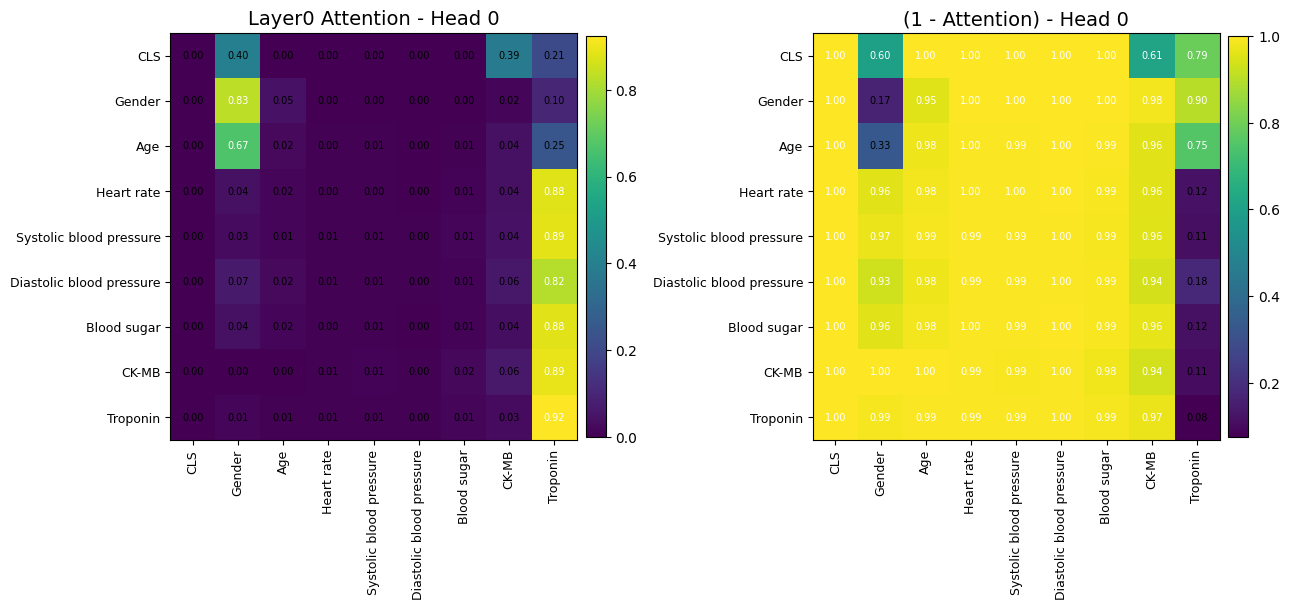

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0101 | std=0.3675
         Gender  | mean=0.0523 | std=2.4399
            Age  | mean=0.0489 | std=1.8516
     Heart rate  | mean=0.0638 | std=1.8220
Systolic blood pressure  | mean=0.0838 | std=2.1454
Diastolic blood pressure  | mean=0.0487 | std=1.3742
    Blood sugar  | mean=0.3550 | std=8.7091
          CK-MB  | mean=-0.3545 | std=6.9557
       Troponin  | mean=-0.1777 | std=3.5356

=== Global embedding statistics ===
global mean: 0.0145
global std : 4.1681


In [6]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



## Affinity Two sample

In [7]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [8]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 1

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on Affinity Frobenius Distance (Label-aware) ===
Reference sample: 1 (label: 1)

Most similar (SAME label): 298 (label: 1)
  → Affinity Frobenius distance: 0.0258

Most different (OTHER label): 825 (label: 0)
  → Affinity Frobenius distance: 0.9725



=== Reference Sample Affinity ===


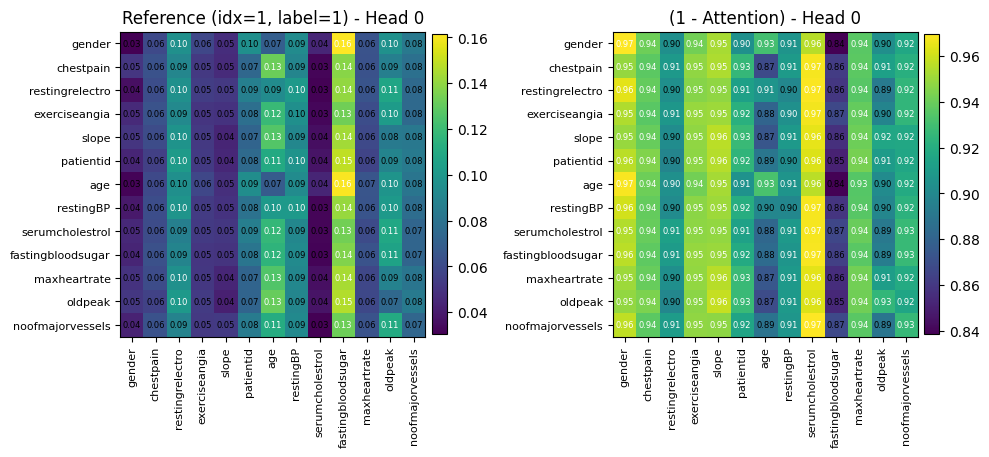


=== Most Similar Sample (SAME Label) Affinity ===
Frobenius distance: 0.0258


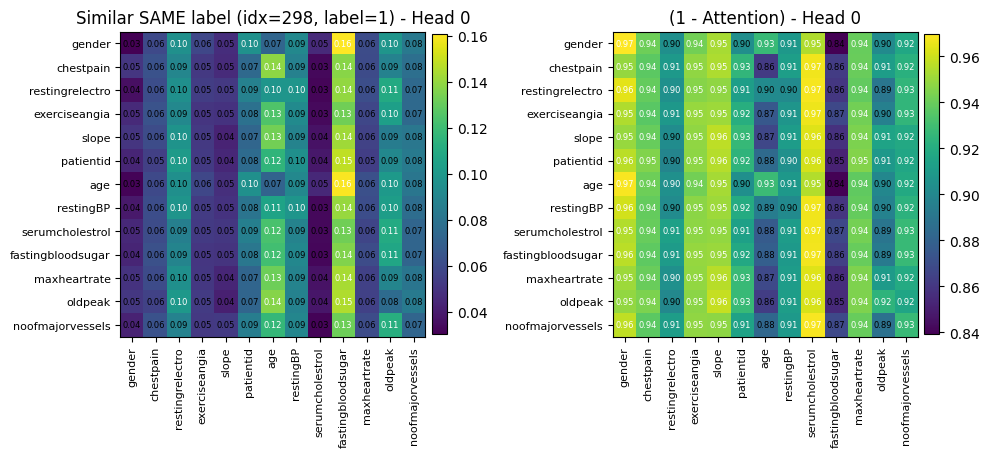


=== Most Different Sample (OTHER Label) Affinity ===
Frobenius distance: 0.9725


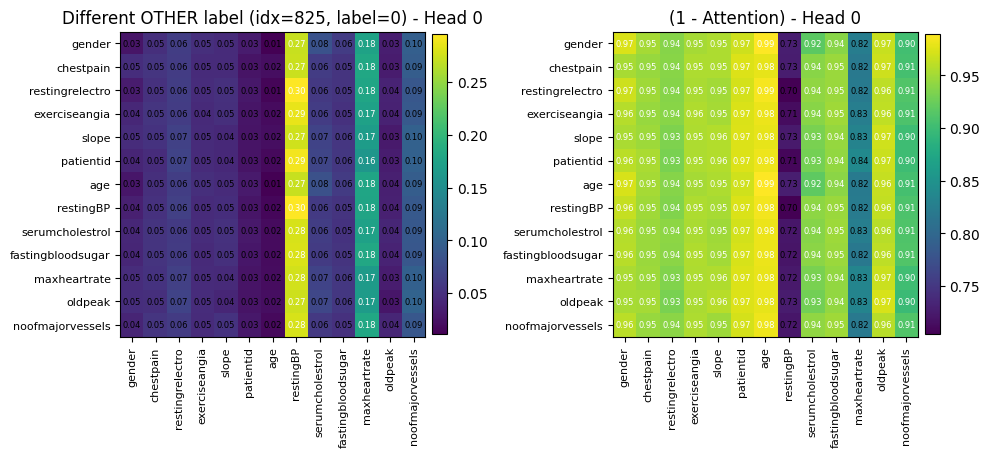

In [9]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

## Multi-Source Joint checkpoint

In [10]:
joint_ckpt_pretrain = torch.load(joint_ckpt_pretrain_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: ['latent_graph.init_node_embeddings', 'latent_graph.init_adj_param']


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-4): 5 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-4): 5 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleLis

## 1. Qualitative Analysis - Label-conditioned Optimal Transport Plan 

In [11]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x M개 LCG Transport Plan 계산
    학습 코드(compute_fgw + z-norm routing)와 완전 일치
    """
    import torch.nn.functional as F
    
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)
        
        N = src_feat.shape[1]
        
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)
        
        lcg_feat_exp = lcg_feat
        lcg_str_exp = lcg_struct
        
        # ---- M_cost: 학습 코드와 동일 ----
        if feat_distance == 'cosine':
            src_norm = F.normalize(src_feat_exp, dim=-1)
            tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
            cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
            M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
        else:
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            M_raw = dist_sq / float(D)
            q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
            M_cost = M_raw / q90
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = float(model.graph_quantizer.alpha)
        reg = float(model.graph_quantizer.reg)
        
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach()  # [M]
        plans = result.plan.detach().cpu().numpy()
        
        # ---- z-norm + softmax: 학습 코드와 동일 ----
        d = distances.unsqueeze(0)  # [1, M]
        d_norm = (d - d.mean(dim=1, keepdim=True)) / d.std(dim=1, keepdim=True).clamp_min(1e-8)
        soft_tau = float(model.graph_quantizer.soft_tau)
        pi = torch.softmax(-d_norm / (soft_tau + 1e-12), dim=1).squeeze(0).cpu().numpy()
        
        all_plans.append(plans)
        all_distances.append(distances.cpu().numpy())
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)
    all_distances = np.array(all_distances)
    all_coordinates = np.array(all_coordinates)
    
    return all_plans, all_distances, all_coordinates


def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = plans.shape[1]  # M에서 자동으로
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(5 * n_lcgs, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    frob_norms_similar = []
    frob_norms_different = []
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]
        plan_sim = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[i]})', fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
                
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                ax.text(0.5, -0.5, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes, ha='center', va='top',
                       fontsize=10, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            else:
                ax.set_xticks([])
            
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle(f'Transport Plans: Reference vs Similar vs Different (across {n_lcgs} LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [12]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model_pretrain, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 5, 13, 8)
Distances shape: (3, 5)
Coordinates shape: (3, 5)

=== Coordinates (pi) ===
Reference: [0.02054751 0.18568237 0.59827    0.00418678 0.19131339]
Similar: [0.0298302  0.21841025 0.49156934 0.00374978 0.2564405 ]
Different: [0.01973253 0.2613452  0.49526522 0.00447531 0.21918179]

=== FGW Distances ===
Reference: [0.46292058 0.396828   0.36169934 0.51068354 0.395931  ]
Similar: [0.45209205 0.3895178  0.36402023 0.51727414 0.3844725 ]
Different: [0.46354532 0.38603622 0.3668582  0.5080572  0.39131457]


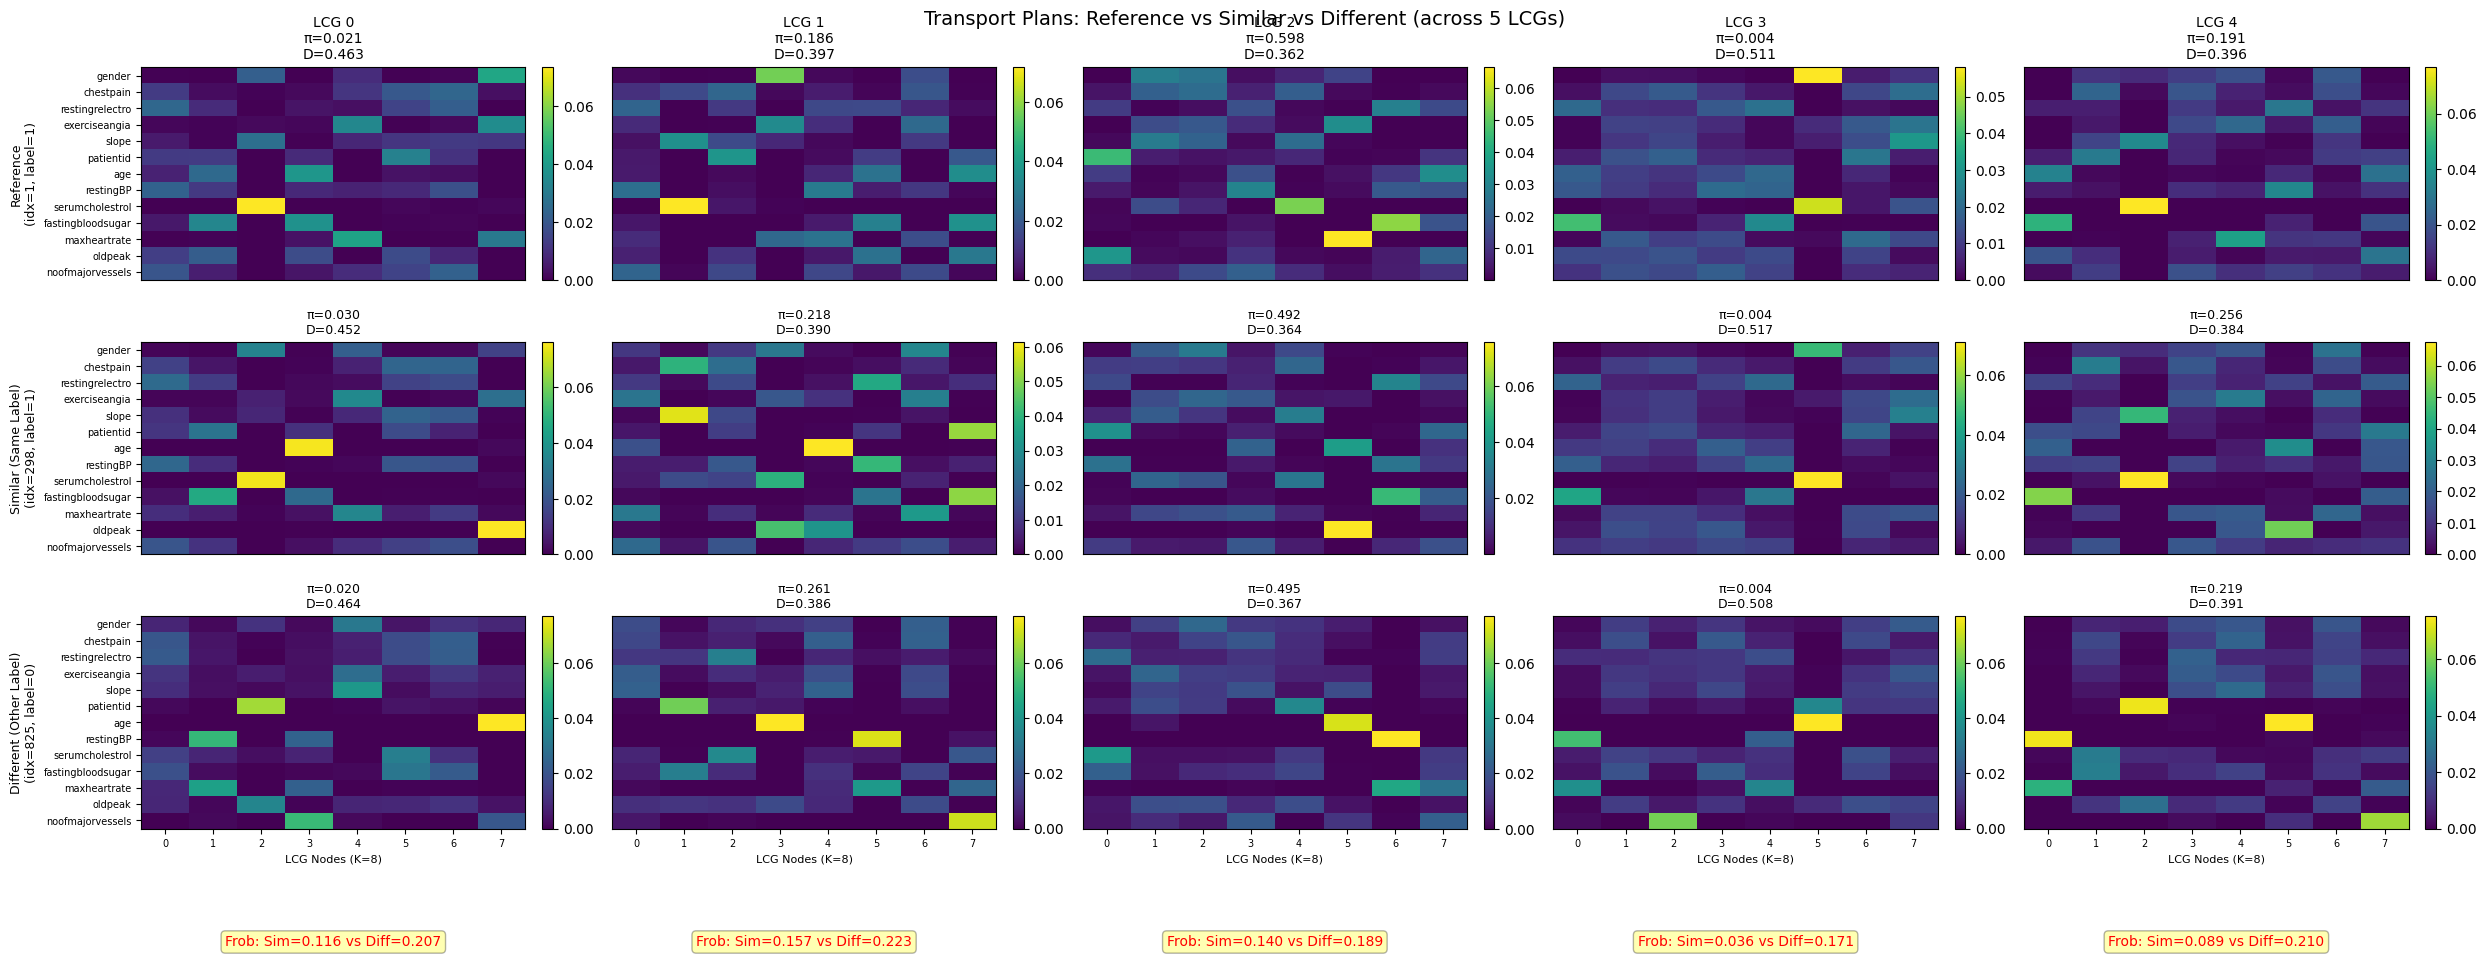

In [13]:
# 호출할 때 sample_indices에 해당하는 labels를 직접 전달
sample_labels = [labels[idx] if idx < len(labels) else '?' for idx in sample_indices]

plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, sample_labels, var_names
)

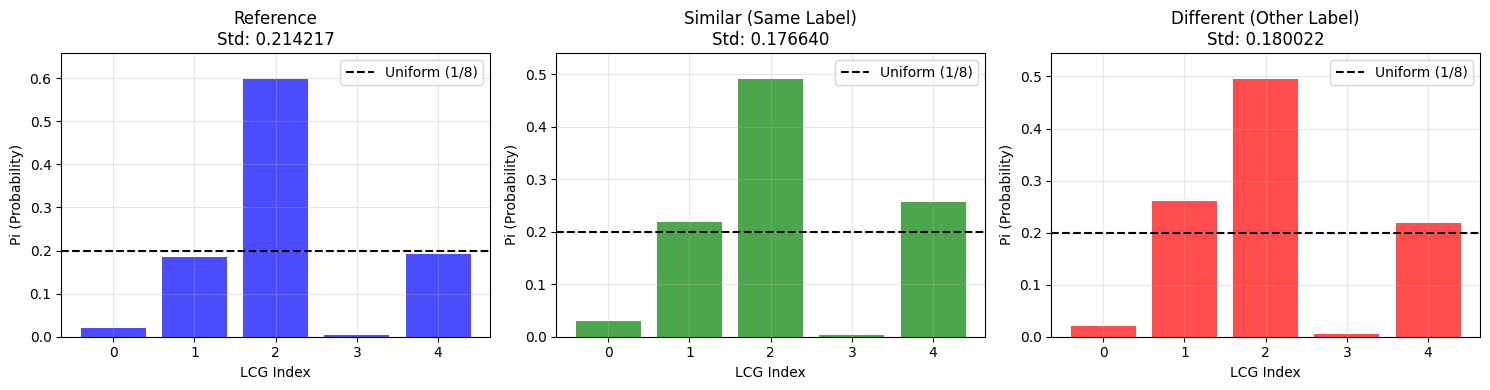

In [14]:
# 시각화: Pi 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(5), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/5, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from ot.batch import solve_gromov_batch

## Qualitative Analysis - Optimal Transport Plan + Coordinate (1)

- Source 별 결과

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 896 (label: 1)
  → distance: 0.3925

Most different (OTHER label): 872 (label: 0)
  → distance: 3.0485

Computing Transport Plans for 3 samples x 8 LCGs...


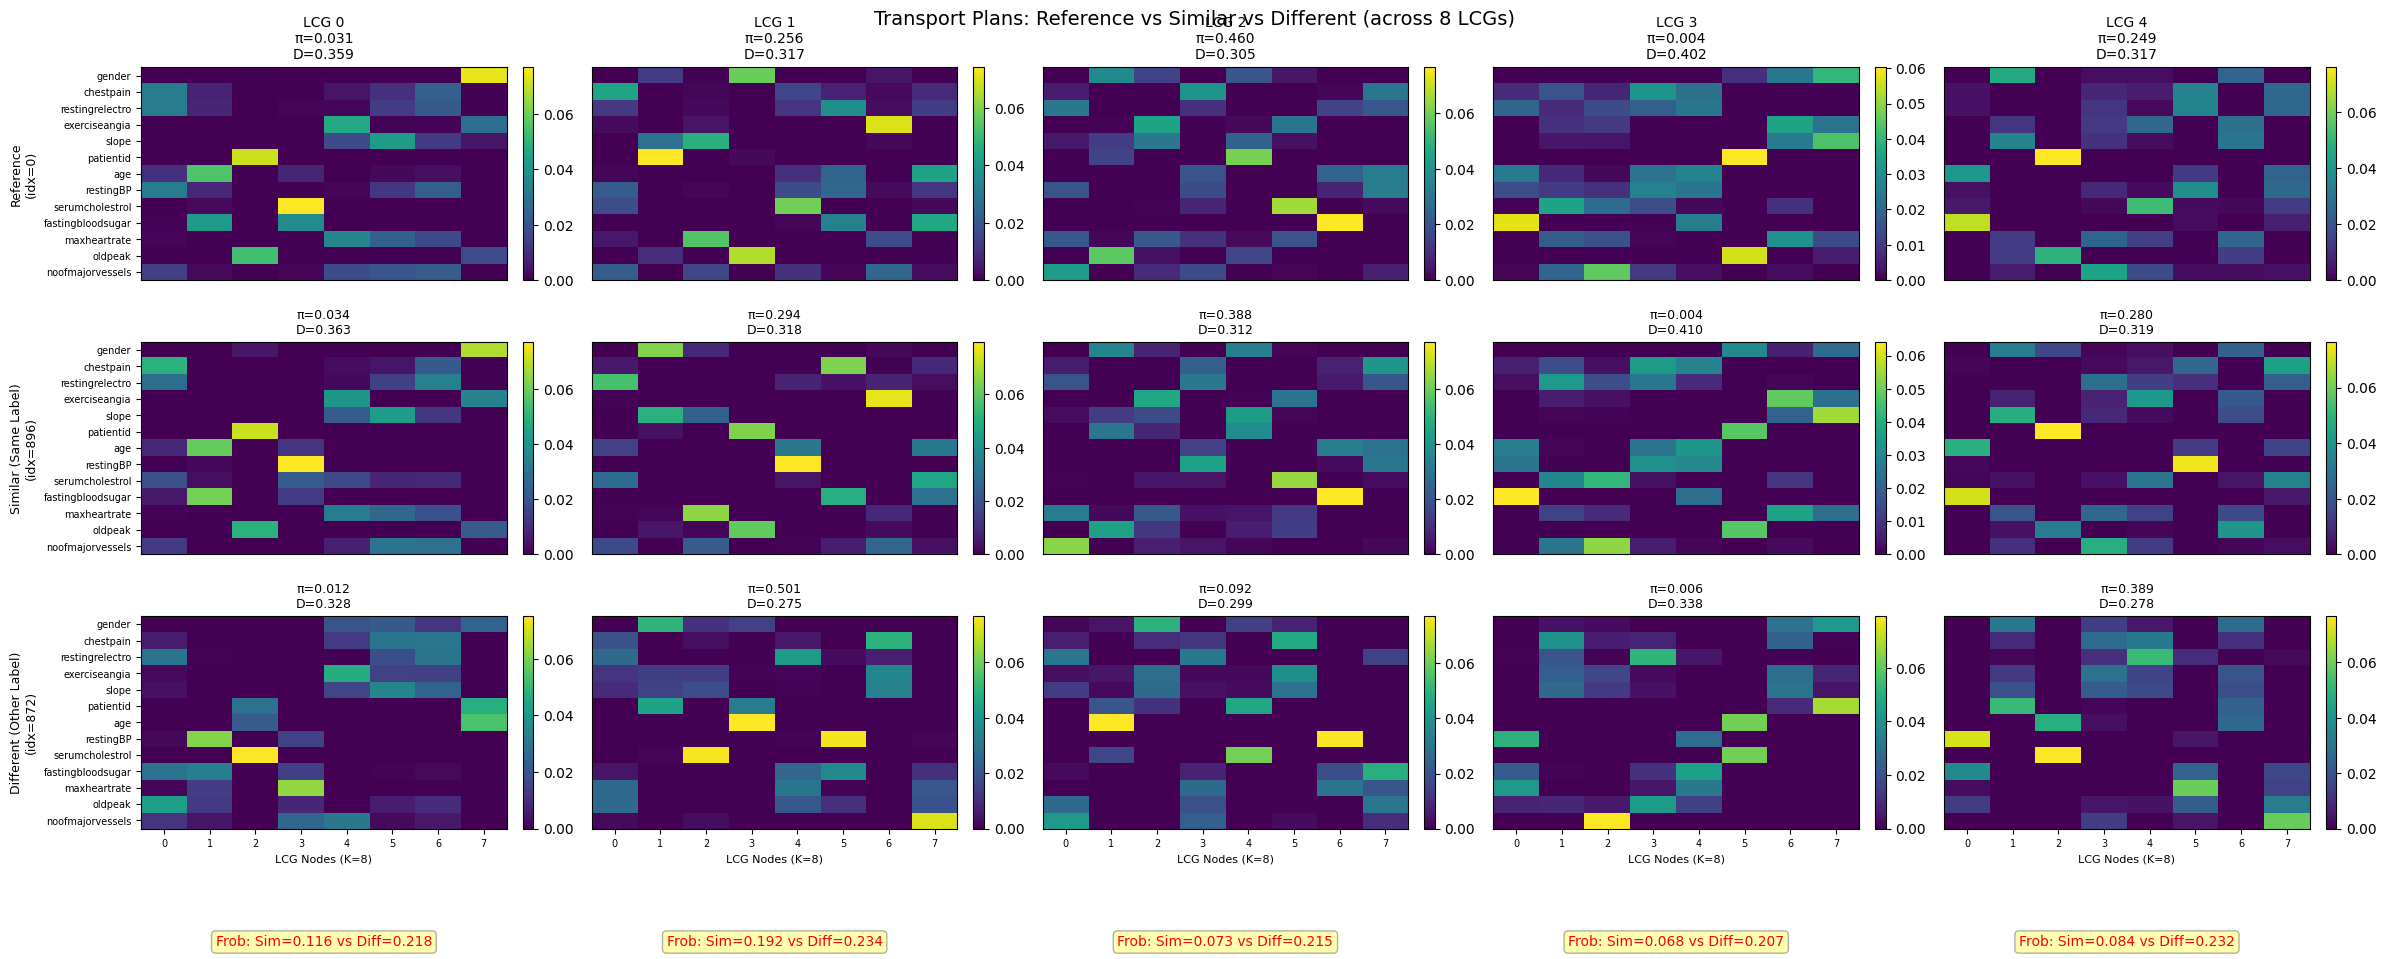

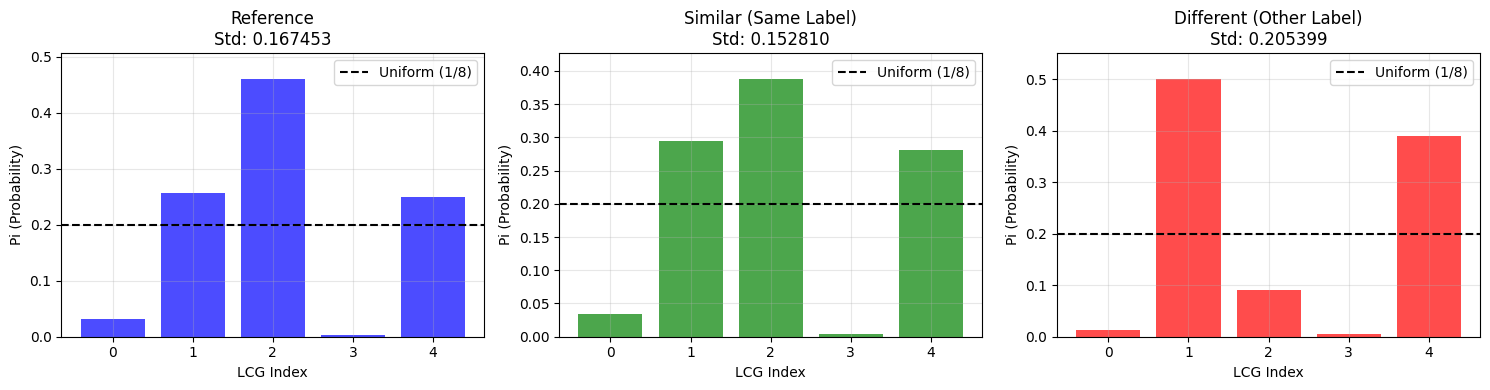

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================================================
# 0) (helper) label-aware ref/sim/diff pick
# =========================================================
def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    n = len(distances)
    ref_label = labels[reference_idx]

    same_label_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_label_mask[reference_idx] = False

    other_label_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    dist_same = distances[reference_idx].copy()
    dist_same[~same_label_mask] = np.inf
    most_similar_same_label_idx = int(np.argmin(dist_same))

    dist_other = distances[reference_idx].copy()
    dist_other[~other_label_mask] = -np.inf
    most_different_other_label_idx = int(np.argmax(dist_other))

    return most_similar_same_label_idx, most_different_other_label_idx


# =========================================================
# 1) collect all samples (embeddings + affinity) from ONE source loader
#    - 너가 준 로직 그대로: last_att(head0) -> var-var -> affinity = 1-att
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn=None):
    """
    Returns:
        all_embeddings: list of [N,D] (CLS 제외 var nodes)
        all_affinities: list of [N,N] (1-attention, Var-Var)
        all_labels: list[int]
        all_feature_names: list[var_names]  (extract_feature_names_fn 제공 시)
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        # desc/name/value gather (너 코드 그대로)
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])

        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)

        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None

        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B,H,T,T] -> head0 -> [B,T,T]
        last_att = last_att[:, 0, :, :]

        # var names
        if extract_feature_names_fn is not None:
            var_names = extract_feature_names_fn(batch)
        else:
            var_names = None

        for b in range(B):
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()
            var_att  = last_att[b, 1:, 1:].detach()
            log_attn = -torch.log(var_att.clamp_min(1e-8))
            q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            affinity = (log_attn / q90).clamp_max(1.0).cpu().numpy()

            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_labels, all_feature_names


# =========================================================
# 2) Frobenius distance matrix (O(n^2))
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n), dtype=np.float32)
    aff_distances = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# 3) FGW plans + pi (너 코드 그대로)
#    NOTE: solve_gromov_batch는 네 세션에 이미 import 되어 있어야 함
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    import torch.nn.functional as F
    
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')

    all_plans = []
    all_distances = []
    all_coordinates = []

    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)
        src_str  = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)
        N = src_feat.shape[1]

        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp  = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)

        if feat_distance == 'cosine':
            src_norm = F.normalize(src_feat_exp, dim=-1)
            tgt_norm = F.normalize(lcg_feat, dim=-1)
            cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
            M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
        else:
            dist_sq = torch.cdist(src_feat_exp, lcg_feat, p=2) ** 2
            M_raw = dist_sq / float(D)
            q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
            M_cost = M_raw / q90

        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K

        alpha = float(model.graph_quantizer.alpha)
        reg   = float(model.graph_quantizer.reg)

        result = solve_gromov_batch(
            src_str_exp, lcg_struct, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )

        plans = result.plan.detach().cpu().numpy()
        
        d = result.value.detach().unsqueeze(0)
        d_norm = (d - d.mean(dim=1, keepdim=True)) / d.std(dim=1, keepdim=True).clamp_min(1e-8)
        soft_tau = float(model.graph_quantizer.soft_tau)
        pi = torch.softmax(-d_norm / (soft_tau + 1e-12), dim=1).squeeze(0).cpu().numpy()

        all_plans.append(plans)
        all_distances.append(result.value.detach().cpu().numpy())
        all_coordinates.append(pi)

    return np.array(all_plans), np.array(all_distances), np.array(all_coordinates)


# =========================================================
# 4) plot grid (너 코드 그대로)
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = plans.shape[1]

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref  = plans[0, j]
        plan_sim  = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]})', fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5, f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes,
                    ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)',
                 fontsize=14, y=0.99)
    plt.show()


# =========================================================
# 5) plot pi 비교 (너 코드 그대로)
# =========================================================
def plot_pi_bars(coordinates):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']

    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[i]
        ax.bar(range(5), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
        ax.axhline(y=1/5, color='black', linestyle='--', label='Uniform (1/8)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# =========================================================
# 6) WRAP-UP (한 방에)
#    - model, loader만 넣으면: 수집 -> 거리 -> ref/sim/diff -> FGW -> 두 plot
#    - var_names는 extract_feature_names로 뽑거나, 없으면 feature_names_list[0]에서 가져옴
# =========================================================
def run_transport_plan_wrapup(
    model,
    loader,
    device,
    source_name="",
    reference_idx=0,
    distance_mode="affinity",   # "affinity" or "embedding"
    extract_feature_names_fn=None,
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(
        model=model,
        loader=loader,
        device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    print(f"Embedding distance matrix shape: {emb_distances.shape}")
    print(f"Affinity distance matrix shape: {aff_distances.shape}")

    if reference_idx < 0 or reference_idx >= len(labels):
        raise IndexError(f"reference_idx out of range: {reference_idx} (n={len(labels)})")

    dist_mat = aff_distances if distance_mode == "affinity" else emb_distances
    similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, dist_mat, labels)

    print(f"\n=== Analysis based on {distance_mode} Frobenius Distance (Label-aware) ===")
    print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
    print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, similar_idx]:.4f}")
    print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, different_idx]:.4f}")

    sample_indices = [reference_idx, similar_idx, different_idx]

    print("\nComputing Transport Plans for 3 samples x 8 LCGs...")
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,
        device=device
    )

    # var_names: 우선 feature_names_list[0] (너 코드처럼)
    # extract_feature_names_fn이 batch->list를 리턴하면 이미 list로 들어있음
    var_names = feature_names_list[0]
    if var_names is None:
        # fallback: generic names
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # ---- plots (너 방식 그대로) ----
    plot_transport_plans_grid(
        plans, coordinates, distances,
        sample_indices=sample_indices,
        labels=labels,
        var_names=var_names
    )
    plot_pi_bars(coordinates)

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "emb_distances": emb_distances,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }


# =========================================================
# 실행 예시
# =========================================================
src = sources[1]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=0,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)


Total samples collected: 270
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (270, 270)
Affinity distance matrix shape: (270, 270)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 1)

Most similar (SAME label): 146 (label: 1)
  → distance: 0.5048

Most different (OTHER label): 218 (label: 0)
  → distance: 3.0225

Computing Transport Plans for 3 samples x 8 LCGs...


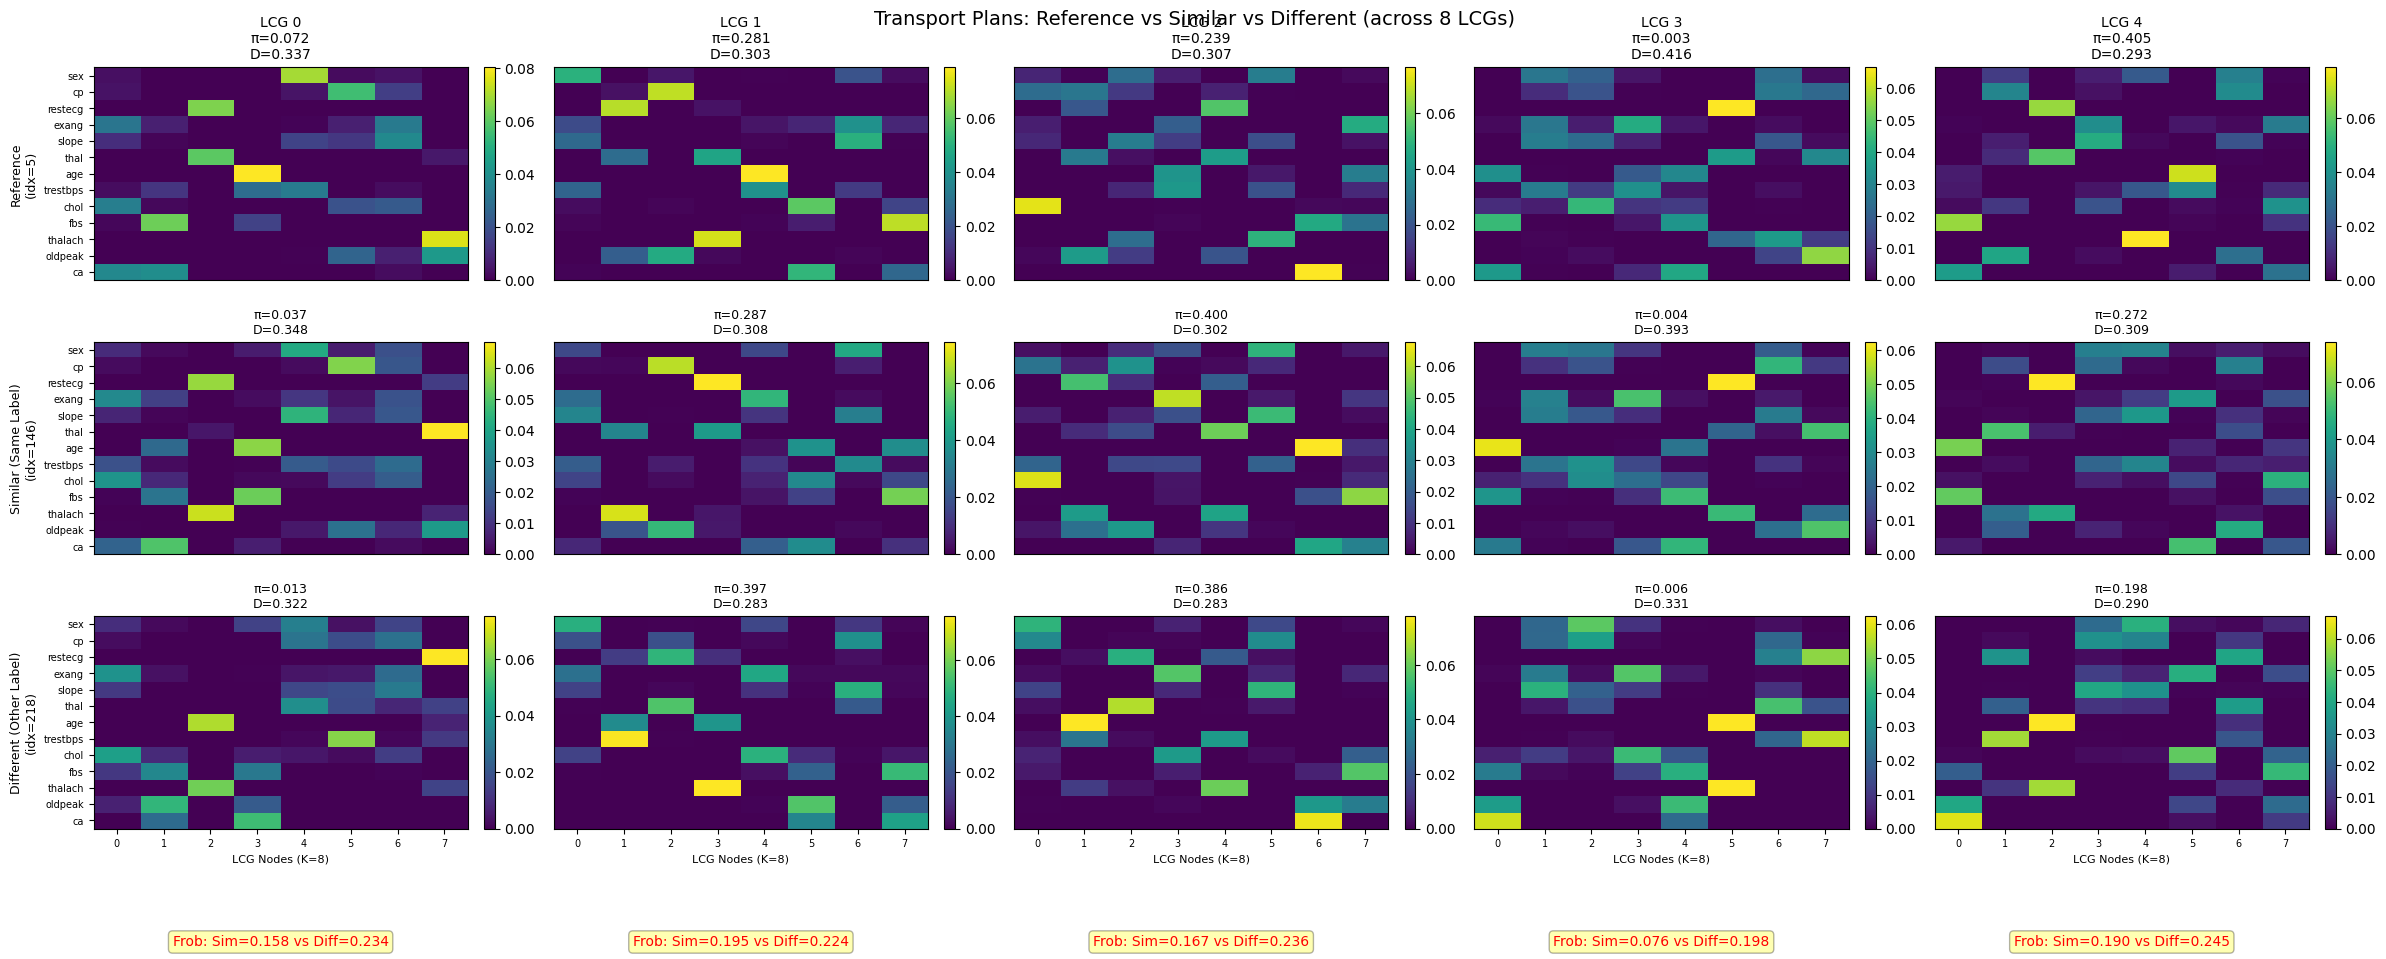

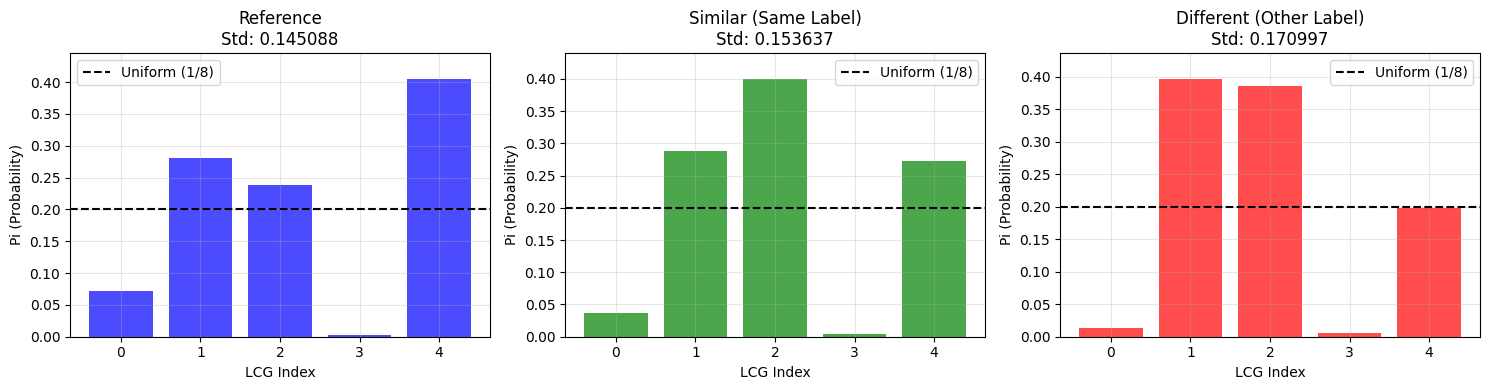

In [17]:
src = sources[2]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

In [18]:
sources[3]

'Erbil_Cardiovascular_Health_Dataset'

Total samples collected: 287
Node embedding shape: (20, 768)
Affinity shape: (20, 20)
Computing Frobenius distances...
Embedding distance matrix shape: (287, 287)
Affinity distance matrix shape: (287, 287)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 1)

Most similar (SAME label): 153 (label: 1)
  → distance: 0.5662

Most different (OTHER label): 213 (label: 0)
  → distance: 2.5624

Computing Transport Plans for 3 samples x 8 LCGs...


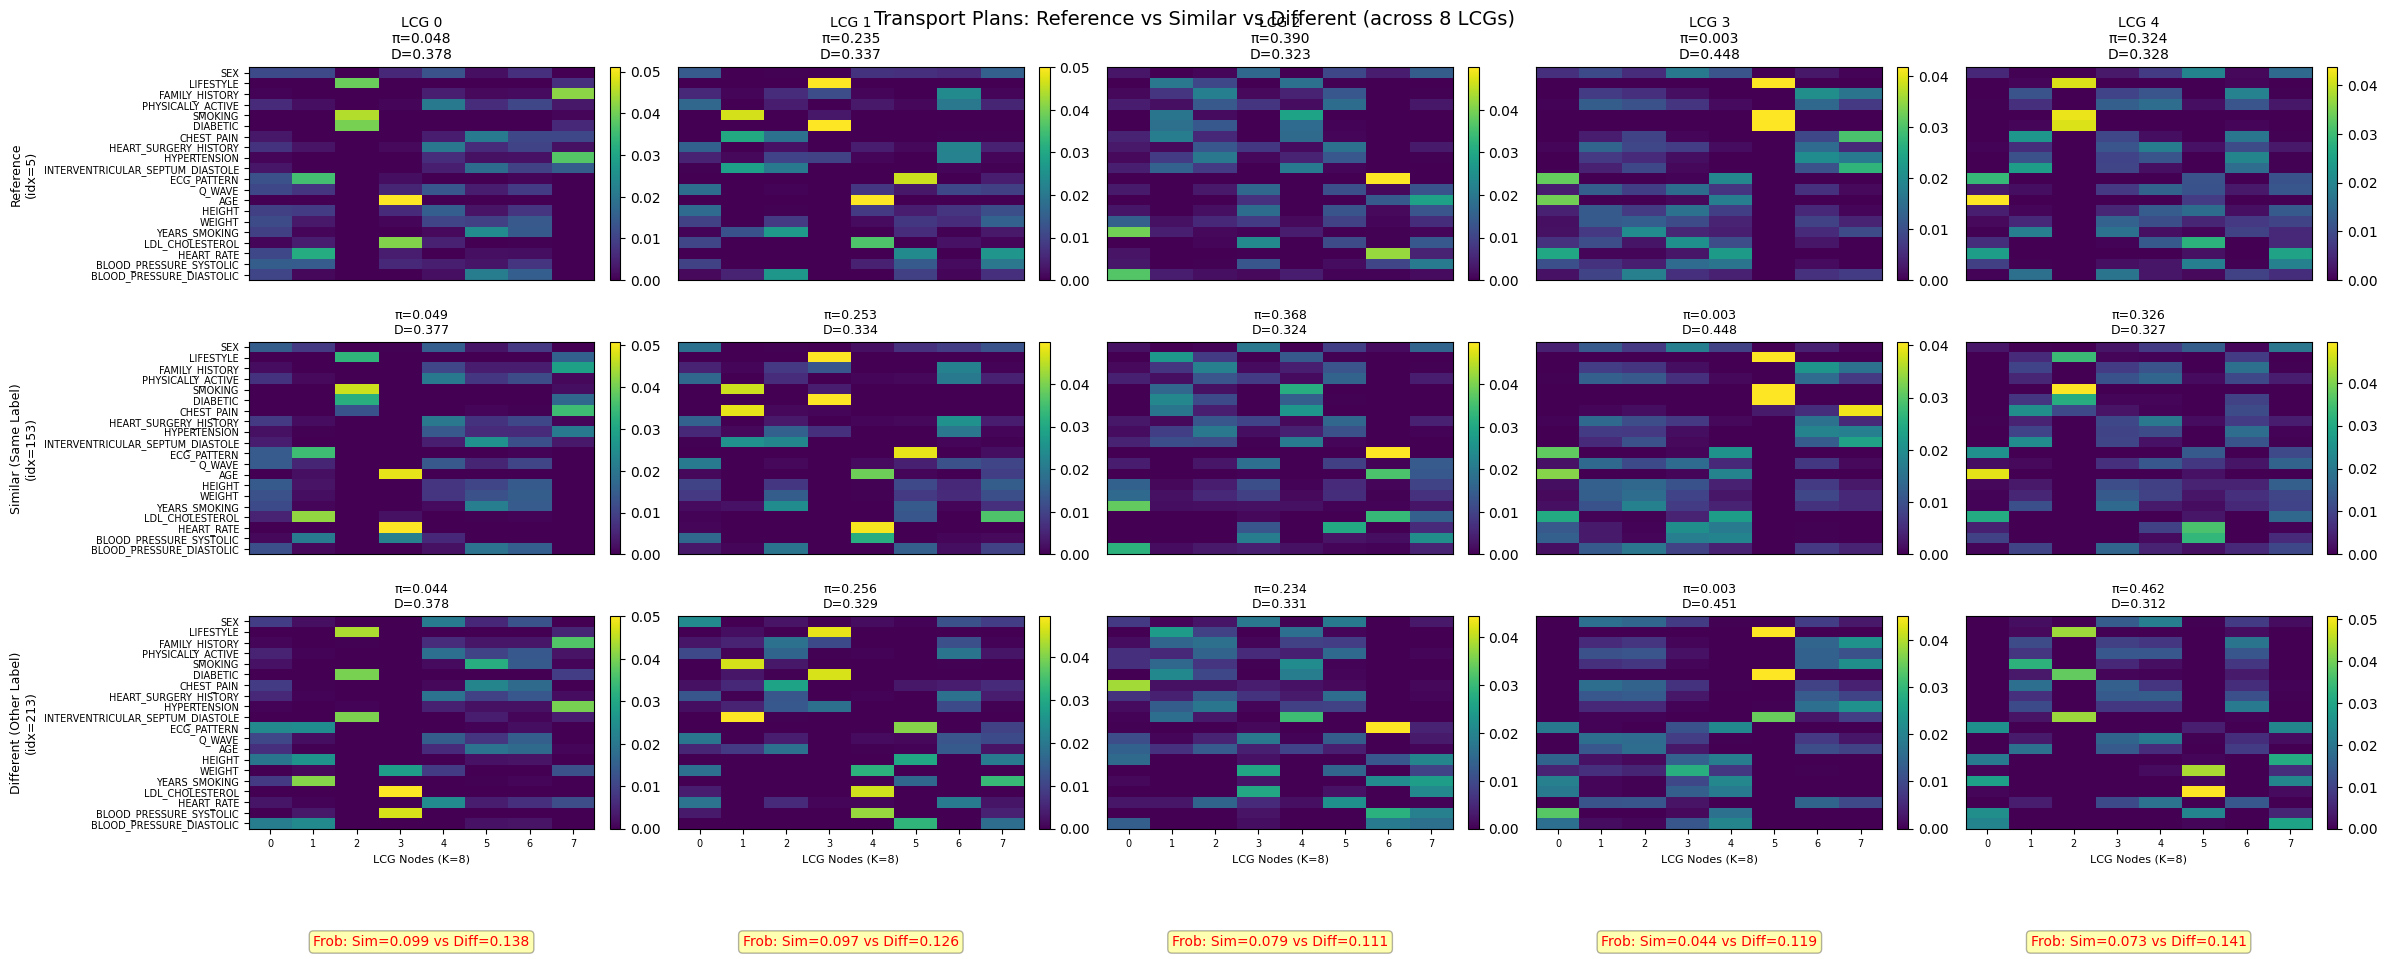

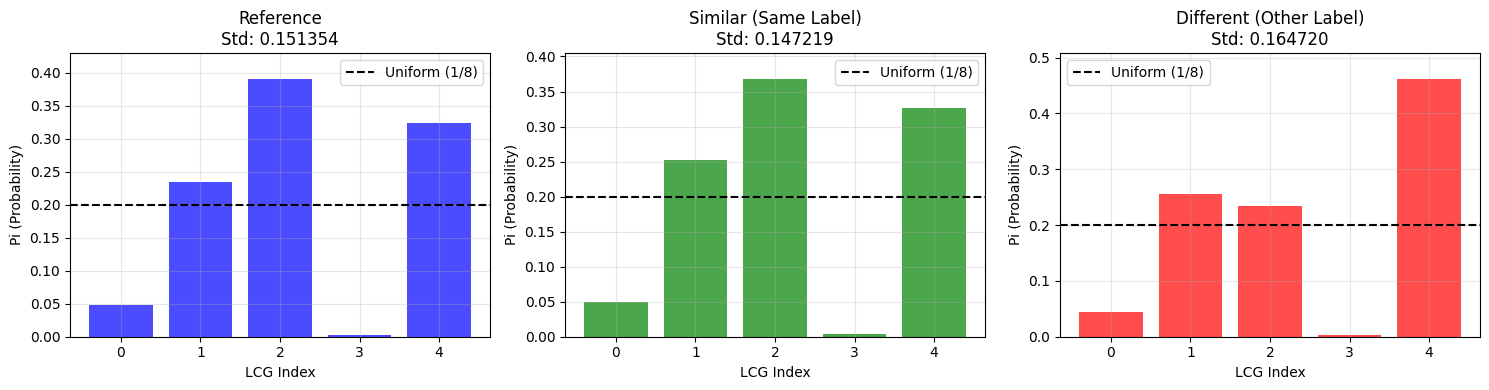

In [19]:
src = sources[3]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

Total samples collected: 1319
Node embedding shape: (8, 768)
Affinity shape: (8, 8)
Computing Frobenius distances...
Embedding distance matrix shape: (1319, 1319)
Affinity distance matrix shape: (1319, 1319)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 0)

Most similar (SAME label): 959 (label: 0)
  → distance: 0.3898

Most different (OTHER label): 347 (label: 1)
  → distance: 2.9632

Computing Transport Plans for 3 samples x 8 LCGs...


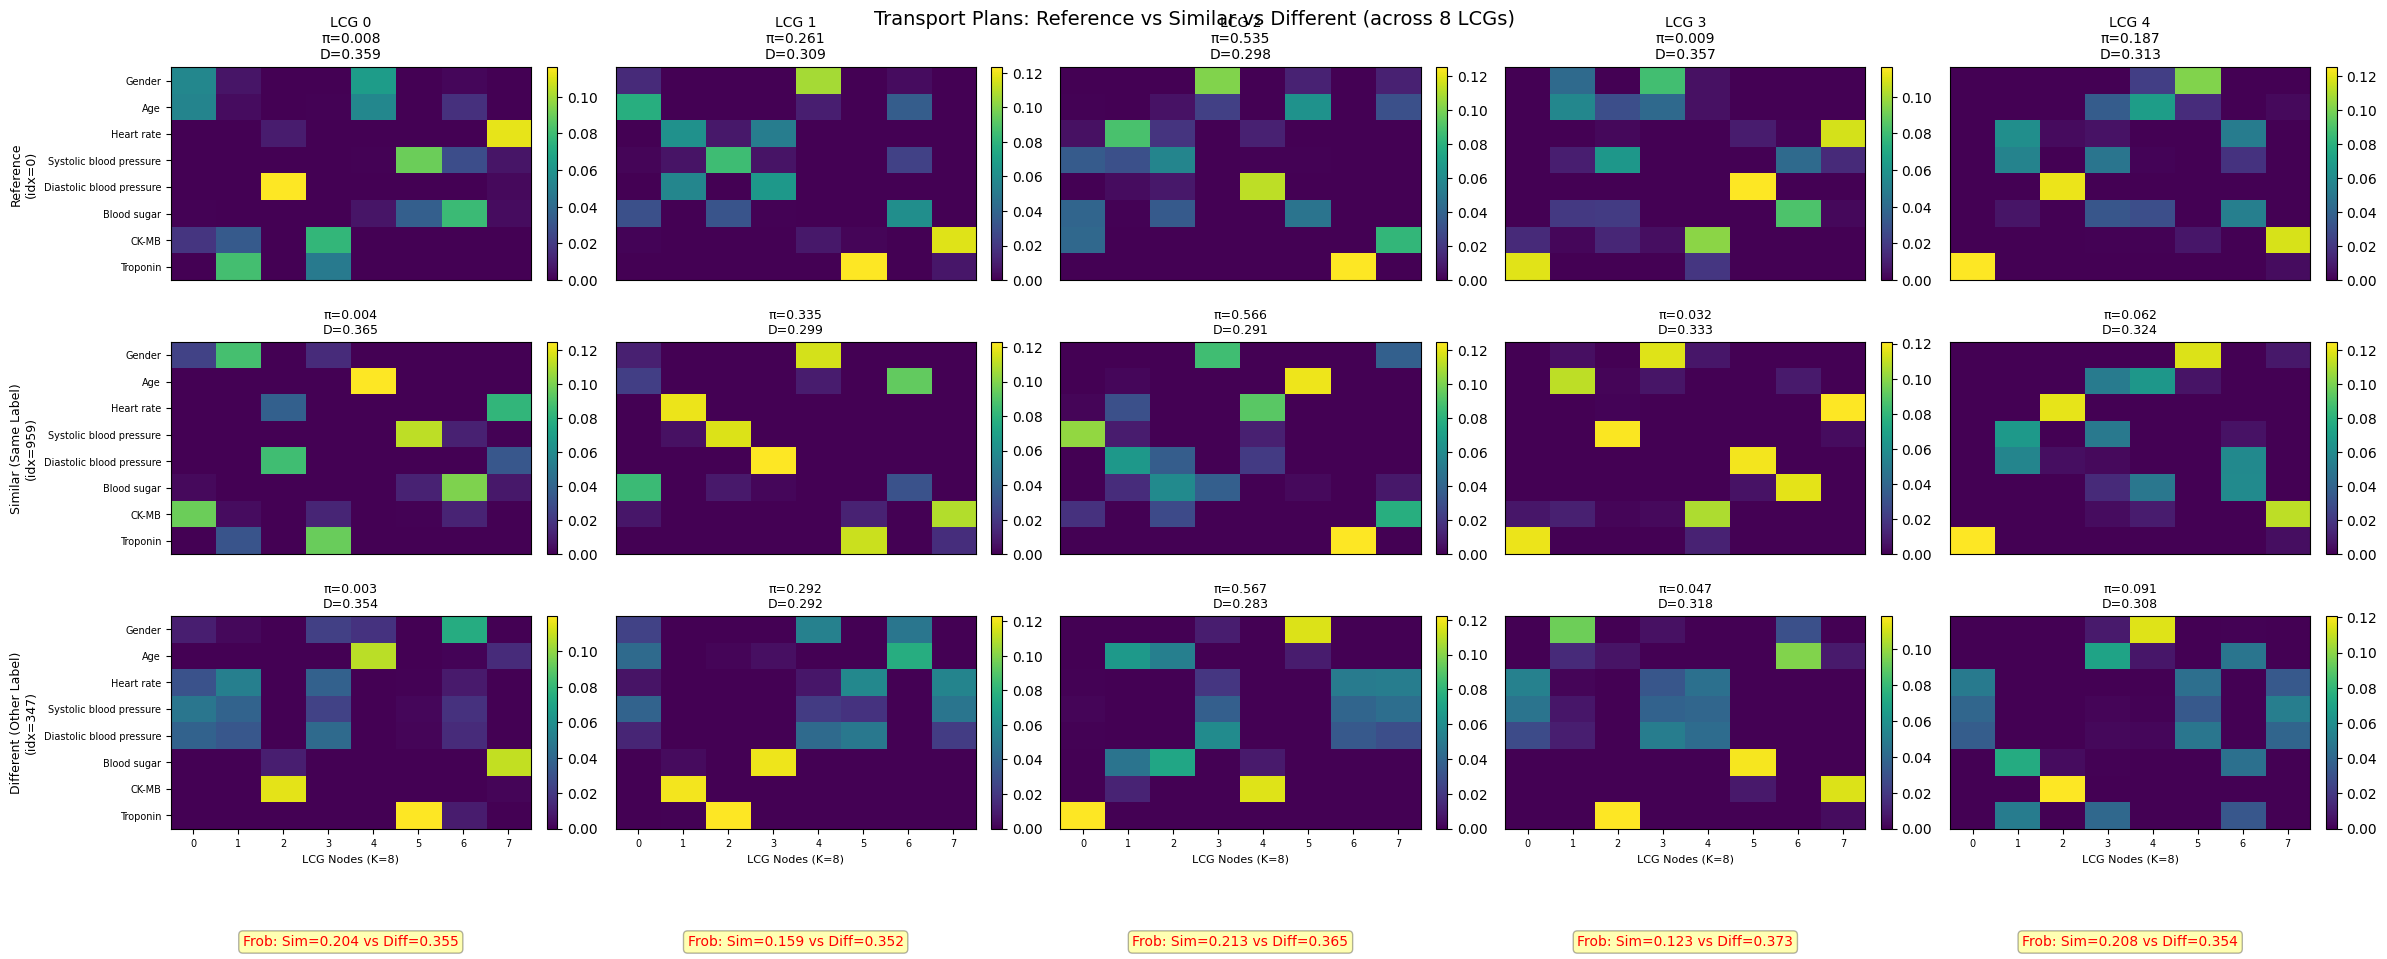

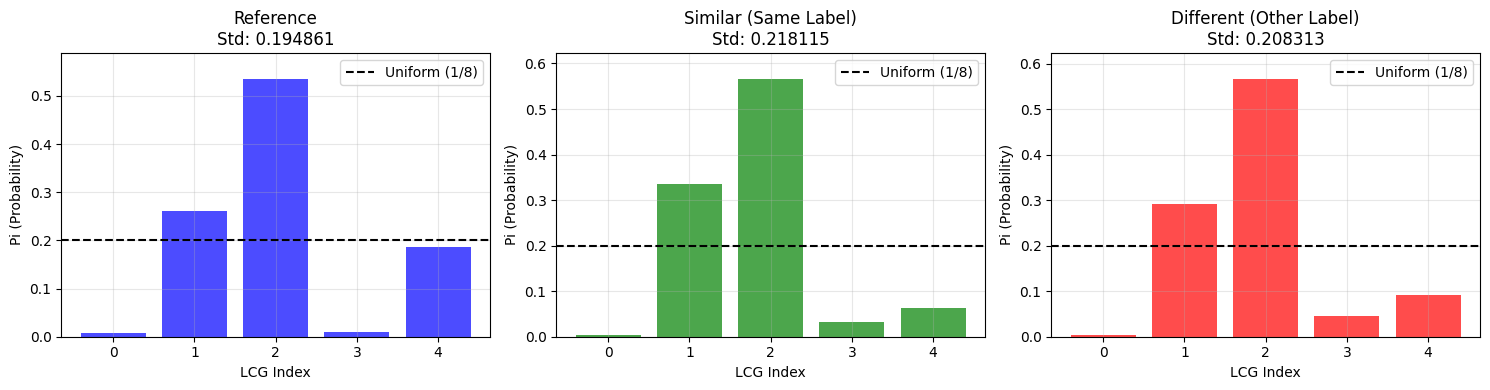

In [20]:
src = sources[0]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=0,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  
)

## Qualitative - Transport Plan, Coordinate (2)

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 네 환경에서 이미 쓰던 것 그대로
# from ot.batch import solve_gromov_batch


# =========================================================
# (A) 너가 준 그대로: loader -> embeddings / affinities / labels 수집
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn):
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)

        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None

        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B,H,T,T] -> head 0
        last_att = last_att[:, 0, :, :]  # [B,T,T]

        # Feature names
        var_names = extract_feature_names_fn(batch)

        for b in range(B):
            # CLS 제외
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N,D]
            var_att  = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N,N]
            affinity = -np.log(var_att + 1e-8)

            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_labels, all_feature_names


# =========================================================
# (B) 너가 준 그대로: Frobenius distance
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# (C) 핵심 수정: reference 기준
#   - similar: 같은 label 중 affinity distance 최소
#   - other  : 다른 label 중 affinity distance 최소 (attention은 유사, label만 다름)
# =========================================================
def find_similar_same_and_similar_other_by_label(reference_idx, distances, labels):
    n = len(labels)
    ref_label = labels[reference_idx]

    same_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_mask[reference_idx] = False

    other_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    if same_mask.sum() == 0:
        raise RuntimeError(f"No same-label sample exists for reference label={ref_label}")
    if other_mask.sum() == 0:
        raise RuntimeError("No other-label sample exists")

    d_same = distances[reference_idx].copy()
    d_same[~same_mask] = np.inf
    similar_idx = int(np.argmin(d_same))

    d_other = distances[reference_idx].copy()
    d_other[~other_mask] = np.inf
    other_idx = int(np.argmin(d_other))  # <-- '다른 레이블인데 attention 유사'를 강제

    return similar_idx, other_idx


# =========================================================
# (D) 너가 준 그대로: transport plan + pi
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    """
    3개 샘플 (ref, similar, different) x M개 LCG Transport Plan 계산
    학습 코드(compute_fgw + z-norm routing)와 완전 일치
    """
    import torch.nn.functional as F
    
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)
        
        N = src_feat.shape[1]
        
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)
        
        lcg_feat_exp = lcg_feat
        lcg_str_exp = lcg_struct
        
        # ---- M_cost: 학습 코드와 동일 ----
        if feat_distance == 'cosine':
            src_norm = F.normalize(src_feat_exp, dim=-1)
            tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
            cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
            M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
        else:
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            M_raw = dist_sq / float(D)
            q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
            M_cost = M_raw / q90
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = float(model.graph_quantizer.alpha)
        reg = float(model.graph_quantizer.reg)
        
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach()  # [M]
        plans = result.plan.detach().cpu().numpy()
        
        # ---- z-norm + softmax: 학습 코드와 동일 ----
        d = distances.unsqueeze(0)  # [1, M]
        d_norm = (d - d.mean(dim=1, keepdim=True)) / d.std(dim=1, keepdim=True).clamp_min(1e-8)
        soft_tau = float(model.graph_quantizer.soft_tau)
        pi = torch.softmax(-d_norm / (soft_tau + 1e-12), dim=1).squeeze(0).cpu().numpy()
        
        all_plans.append(plans)
        all_distances.append(distances.cpu().numpy())
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)
    all_distances = np.array(all_distances)
    all_coordinates = np.array(all_coordinates)
    
    return all_plans, all_distances, all_coordinates


# =========================================================
# (E) 너가 준 그대로: 3x8 plan grid
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = plans.shape[1]

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref  = plans[0, j]
        plan_sim  = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]})', fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5, f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes,
                    ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)',
                 fontsize=14, y=0.99)
    plt.show()


# =========================================================
# (F) 요청한 2x3: (위) coordinate bar / (아래) attention map
#   - coordinate 색: 파란/초록/빨강 (원래 코드 그대로)
#   - y-limit / uniform line / grid도 원래 코드 그대로
#   - [수정] colorbar가 attention map 위에 겹치지 않게: 오른쪽에 전용 cax를 만들어서 밖으로 뺌
# =========================================================
def plot_coord_and_attention_2x3(sample_indices, coordinates, affinities, labels, var_names, title_prefix=""):
    # coordinates: [3,M]
    M = coordinates.shape[1]

    # affinity = 1 - att 이었으니 attention 복원
    atts = [1.0 - affinities[idx] for idx in sample_indices]

    # attention 비교 가능하게 shared scale
    vmin = min(float(np.min(a)) for a in atts)
    vmax = max(float(np.max(a)) for a in atts)

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))

    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']  # <-- 원래 코드 그대로

    # ---- top row: coordinate (원래 스타일 그대로) ----
    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[0, i]
        ax.bar(range(M), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, float(coord.max()) * 1.1)])
        ax.axhline(y=1/M, color='black', linestyle='--', label=f'Uniform (1/{M})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # ---- bottom row: attention map ----
    ims = []
    for i in range(3):
        ax = axes[1, i]
        im = ax.imshow(atts[i], cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        ims.append(im)
        ax.set_title('Attention (Var-Var)')
        ax.set_xlabel('variables')
        ax.set_ylabel('variables')

        ax.set_xticks(range(len(var_names)))
        ax.set_yticks(range(len(var_names)))
        ax.set_xticklabels(var_names, rotation=90, fontsize=7)
        ax.set_yticklabels(var_names, fontsize=7)

    fig.suptitle(f'{title_prefix} 2x3: Coordinate(pi) + Attention map', fontsize=14)

    # [핵심] 오른쪽 공간을 먼저 확보하고, colorbar 전용 축(cax)을 만들어 바깥으로 뺌
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # <-- 오른쪽 8% 비워두기

    # bottom-right attention axis 기준으로 cax 위치 계산(겹침 방지)
    pos = axes[1, 2].get_position()
    cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.012, pos.height])  # (x, y, w, h)
    fig.colorbar(ims[-1], cax=cax)

    plt.show()


# =========================================================
# (G) WRAP-UP: 한 방에 실행
#   reference 기준:
#     - similar: same label & attention 유사(aff dist 최소)
#     - other  : other label & attention 유사(aff dist 최소)
# =========================================================
def run_ref_sim_other_attention_viz(
    model,
    loader,
    device,
    source_name,
    extract_feature_names_fn,
    reference_idx=0
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(
        model=model,
        loader=loader,
        device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    similar_idx, other_idx = find_similar_same_and_similar_other_by_label(
        reference_idx=reference_idx,
        distances=aff_distances,
        labels=labels
    )

    print("\n=== Picked indices ===")
    print(f"Reference: {reference_idx} (label={labels[reference_idx]})")
    print(f"Similar (SAME label, min aff-dist): {similar_idx} (label={labels[similar_idx]}), dist={aff_distances[reference_idx, similar_idx]:.4f}")
    print(f"Other  (OTHER label, min aff-dist): {other_idx} (label={labels[other_idx]}), dist={aff_distances[reference_idx, other_idx]:.4f}")

    sample_indices = [int(reference_idx), int(similar_idx), int(other_idx)]

    # var names
    var_names = feature_names_list[0]
    if var_names is None:
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # FGW + 시각화
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,
        device=device
    )

    # 3x8 (원래 코드)
    plot_transport_plans_grid(
        plans=plans,
        coordinates=coordinates,
        distances=distances,
        sample_indices=sample_indices,
        labels=labels,
        var_names=var_names
    )

    # 2x3 (요청한 것 + coordinate 색/스타일 원래대로)  <-- 여기 colorbar 겹침 수정됨
    plot_coord_and_attention_2x3(
        sample_indices=sample_indices,
        coordinates=coordinates,
        affinities=affinities,
        labels=labels,
        var_names=var_names,
        title_prefix=f"[{source_name}]"
    )

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }




Total samples collected: 1319
Node embedding shape: (8, 768)
Affinity shape: (8, 8)
Computing Frobenius distances...

=== Picked indices ===
Reference: 16 (label=0)
Similar (SAME label, min aff-dist): 1316 (label=0), dist=0.7748
Other  (OTHER label, min aff-dist): 686 (label=1), dist=1.0689


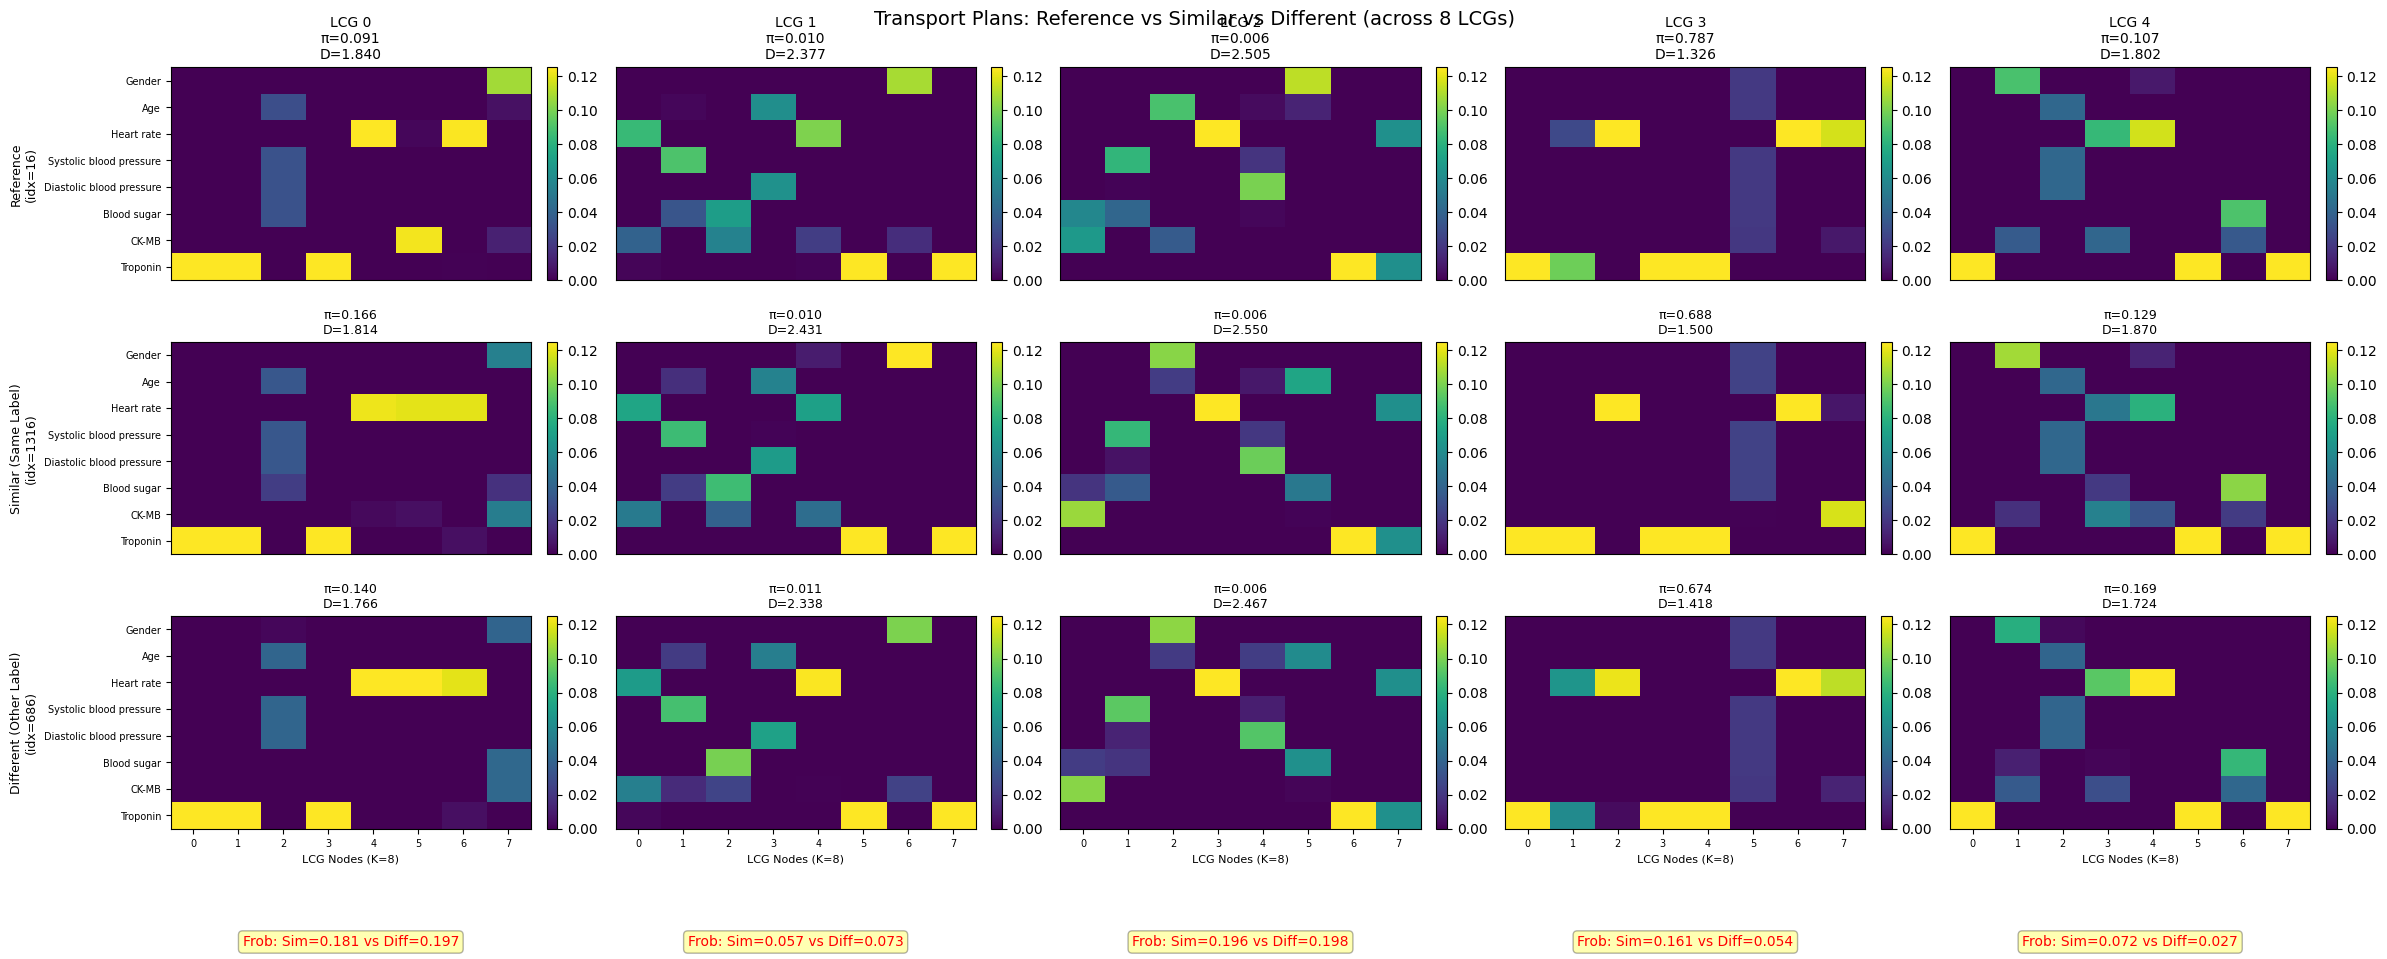

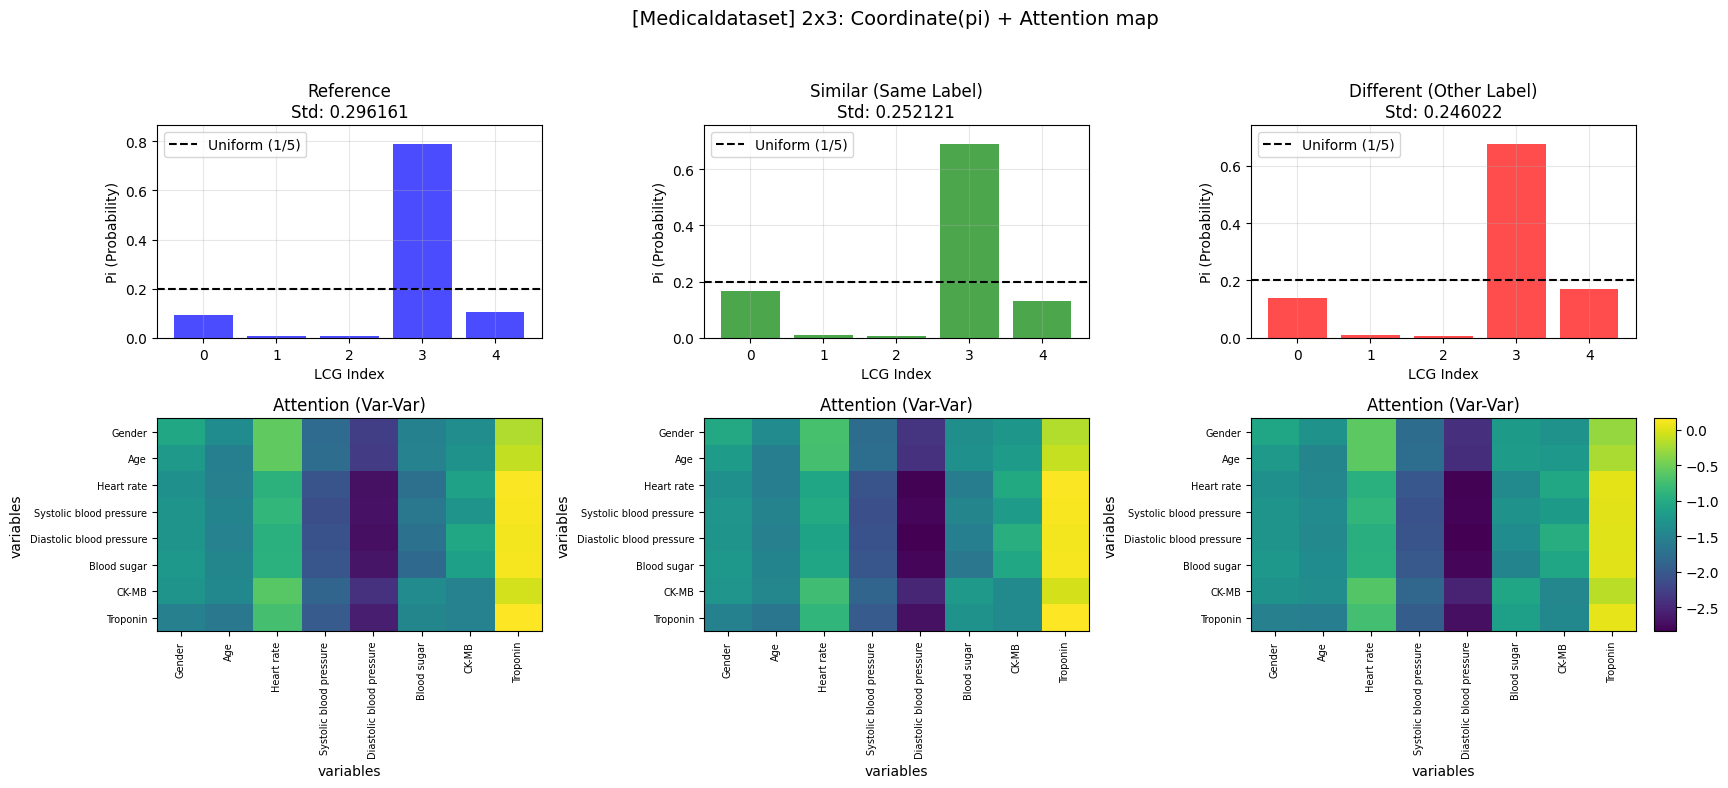

In [22]:

# =========================================================
# 실행 예시
# =========================================================
src = sources[0]
loader = loaders[src]
out = run_ref_sim_other_attention_viz(
    model=joint_model_pretrain,
    loader=loader,
    device=device,
    source_name=src,
    extract_feature_names_fn=extract_feature_names,
    reference_idx=16
)

## Coordinate Clustering

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ot.batch import solve_gromov_batch

@torch.no_grad()
def _pi_batch(model, batch, device):
    import torch.nn.functional as F
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    name_embeddings, value_embeddings = [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    name  = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)
    B = value.size(0)

    x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

    last_att = None
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        last_att = att
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    src_feat = x_basis[:, 1:, :].contiguous()
    var_att = last_att[:, 0, 1:, 1:]
    log_attn = -torch.log(var_att.clamp_min(1e-8))
    with torch.no_grad():
        q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
    src_str = (log_attn / q90).clamp_max(1.0)

    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    N = src_feat.shape[1]

    src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B * M, N, D)
    src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B * M, N, N)
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B * M, K, D)
    lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B * M, K, K)

    # 수정: cosine M_cost (학습 코드와 동일)
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    if feat_distance == 'cosine':
        src_norm = F.normalize(src_feat_exp, dim=-1)
        tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
        cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
        M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
    else:
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        M_raw = dist_sq / float(D)
        q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
        M_cost = M_raw / q90

    a = torch.ones(B * M, N, device=device) / N
    b = torch.ones(B * M, K, device=device) / K

    alpha = float(model.graph_quantizer.alpha)
    reg   = float(model.graph_quantizer.reg)

    result = solve_gromov_batch(
        src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
        a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
    )

    d = result.value.reshape(B, M)
    
    # 수정: z-norm + softmax (학습 코드와 동일)
    d_norm = (d - d.mean(dim=1, keepdim=True)) / d.std(dim=1, keepdim=True).clamp_min(1e-8)
    soft_tau = float(model.graph_quantizer.soft_tau)
    pi = torch.softmax(-d_norm / (soft_tau + 1e-12), dim=1)
    
    return pi.detach().cpu().numpy()

def pi_wrap(model, loaders_by_src, device, max_batches=200, per_src=False, title="pi_pop"):
    model.eval()

    def _collect_for_loader(loader):
        pis = []
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break
            pi = _pi_batch(model, batch, device)   # [B,M]
            pis.append(pi)
        return np.concatenate(pis, axis=0) if len(pis) > 0 else None  # [N,M]

    def _plot(pis, tag):
        M = pis.shape[1]
        mean_pi = pis.mean(axis=0)                 # [M]
        usage = np.bincount(pis.argmax(axis=1), minlength=M) / pis.shape[0]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(range(M), mean_pi)
        axes[0].axhline(1.0/M, linestyle="--")
        axes[0].set_title(f"{tag} | mean(pi)")
        axes[0].set_xlabel("LCG index"); axes[0].set_ylabel("prob")

        axes[1].bar(range(M), usage)
        axes[1].axhline(1.0/M, linestyle="--")
        axes[1].set_title(f"{tag} | argmax usage")
        axes[1].set_xlabel("LCG index"); axes[1].set_ylabel("fraction")

        plt.tight_layout()
        plt.show()

    if per_src:
        out = {}
        for src, loader in loaders_by_src.items():
            pis = _collect_for_loader(loader)
            if pis is None:
                continue
            _plot(pis, f"{title}:{src} (n={pis.shape[0]})")
            out[src] = pis
        return out
    else:
        all_pis = []
        for src, loader in loaders_by_src.items():
            pis = _collect_for_loader(loader)
            if pis is None:
                continue
            all_pis.append(pis)
        pis = np.concatenate(all_pis, axis=0)
        _plot(pis, f"{title}:POOLED (n={pis.shape[0]})")
        return pis


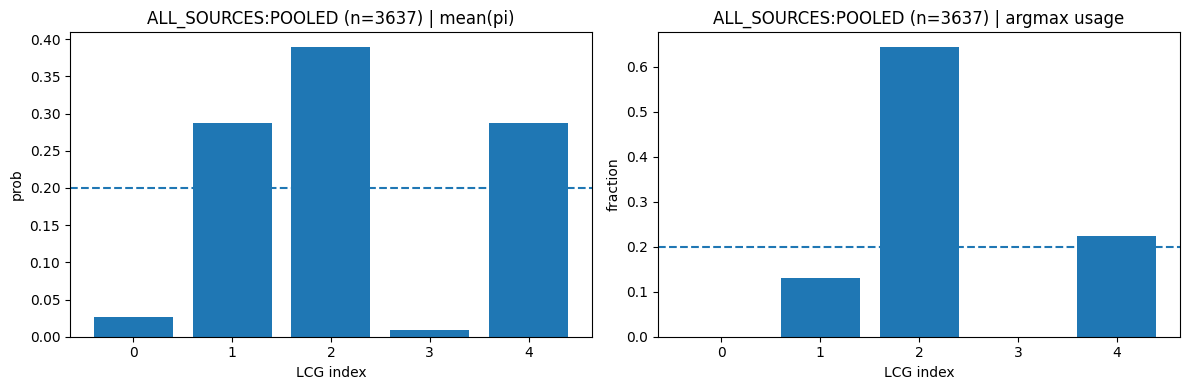

In [24]:
loaders_by_src = {src: loaders[src] for src in sources}  
pis = pi_wrap(model, loaders_by_src, device, max_batches=None, per_src=False, title="ALL_SOURCES")


In [25]:
@torch.no_grad()
def _d_pi_batch(model, batch, device):
    model.eval()
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    name_embeddings, value_embeddings = [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings']):
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if ('num_name_embeddings' in batch) and ('num_prompt_embeddings' in batch):
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    name  = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)
    B = value.size(0)

    x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
    last_att = None
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        last_att = att
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    src_feat = x_basis[:, 1:, :].contiguous()
    var_att  = last_att[:, 0, 1:, 1:].contiguous()
    src_str  = (1.0 - var_att).contiguous()

    lcg_feat, lcg_str = model.latent_graph()
    M, K, D = lcg_feat.shape
    N = src_feat.shape[1]

    src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B * M, N, D)
    src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B * M, N, N)
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B * M, K, D)
    lcg_str_exp  = lcg_str.unsqueeze(0).expand(B, M, K, K).reshape(B * M, K, K)

    # ---- M_cost: cosine (학습 코드와 동일) ----
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    if feat_distance == 'cosine':
        import torch.nn.functional as F
        src_norm = F.normalize(src_feat_exp, dim=-1)
        tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
        cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
        M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
    else:
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        M_raw = dist_sq / float(D)
        q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
        M_cost = M_raw / q90

    a = torch.ones(B * M, N, device=device) / N
    b = torch.ones(B * M, K, device=device) / K

    alpha = float(model.graph_quantizer.alpha)
    reg   = float(model.graph_quantizer.reg)

    result = solve_gromov_batch(
        src_str_exp, lcg_str_exp, M=M_cost,
        alpha=alpha, reg=reg, a=a, b=b,
        max_iter=10, tol=1e-3, grad='envelope'
    )

    d = result.value.reshape(B, M)
    
    # ---- z-norm + softmax (학습 코드와 동일) ----
    d_norm = (d - d.mean(dim=1, keepdim=True)) / d.std(dim=1, keepdim=True).clamp_min(1e-8)
    soft_tau = float(model.graph_quantizer.soft_tau)
    pi = torch.softmax(-d_norm / (soft_tau + 1e-12), dim=1)

    return d.detach().cpu().numpy(), pi.detach().cpu().numpy()

In [26]:
@torch.no_grad()
def collect_d_pi(model, loaders_by_src, device, max_batches=None):
    import torch.nn.functional as F
    model.eval()
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    d_all, pi_all = [], []
    for src, loader in loaders_by_src.items():
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break
            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            name_embeddings, value_embeddings = [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name  = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            B, N, D = value.shape

            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            src_feat = x_basis[:, 1:, :].contiguous()
            var_att = last_att[:, 0, 1:, 1:]
            log_attn = -torch.log(var_att.clamp_min(1e-8))
            with torch.no_grad():
                q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            src_str = (log_attn / q90).clamp_max(1.0)

            lcg_feat, lcg_struct = model.latent_graph()
            M, K, _ = lcg_feat.shape

            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)

            if feat_distance == 'cosine':
                src_norm = F.normalize(src_feat_exp, dim=-1)
                tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
                cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
                M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
            else:
                dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
                M_raw = dist_sq / float(D)
                q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
                M_cost = M_raw / q90

            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            alpha = float(model.graph_quantizer.alpha)
            reg   = float(model.graph_quantizer.reg)

            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost,
                alpha=alpha, reg=reg, a=a, b=b,
                max_iter=10, tol=1e-3, grad='envelope'
            )

            d = result.value.reshape(B, M)
            d_norm = (d - d.mean(dim=1, keepdim=True)) / d.std(dim=1, keepdim=True).clamp_min(1e-8)
            soft_tau = float(model.graph_quantizer.soft_tau)
            pi = torch.softmax(-d_norm / (soft_tau + 1e-12), dim=1)

            d_all.append(d.cpu().numpy())
            pi_all.append(pi.cpu().numpy())

    return np.concatenate(d_all, axis=0), np.concatenate(pi_all, axis=0)

samples: 3637 M: 5

mean(pi): [0.0266 0.2877 0.3898 0.0085 0.2873]
usage(argmax pi): [0.     0.1317 0.6448 0.     0.2235]

mean(d) per LCG: [0.354667 0.307335 0.303871 0.381619 0.307151]
best LCGs by mean(d): [2 4 1 0]  (smaller is better)

Gap(d2-d1): mean= 0.008821474 median= 0.0074201524 p90= 0.017362111806869508 min= 1.013279e-06 max= 0.06793359

Gap(pi_top1 - pi_top2): mean= 0.177922 median= 0.15102145 p90= 0.362380051612854


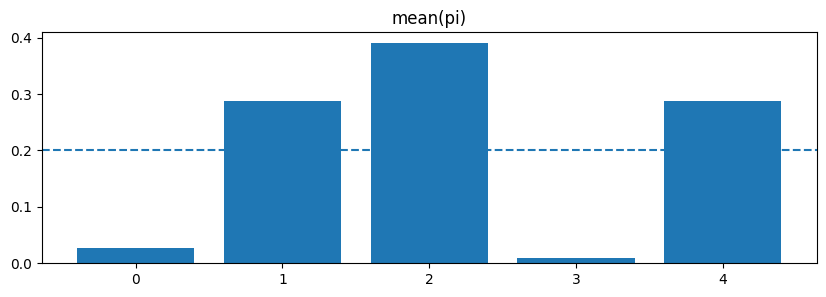

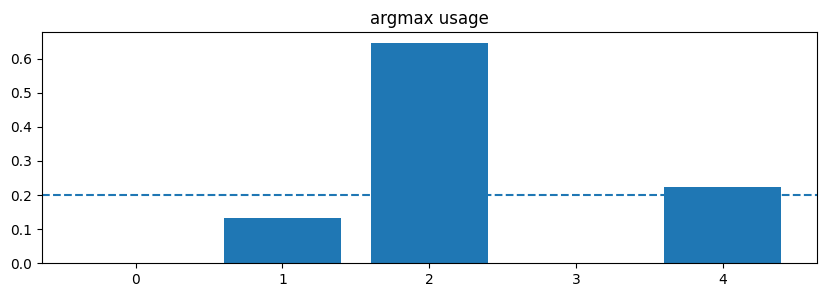

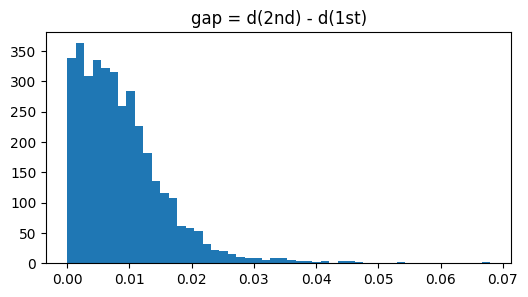

In [27]:
# 1) 뽑기
d_all, pi_all = collect_d_pi(model, loaders, device, max_batches=None)

M = pi_all.shape[1]
S = pi_all.shape[0]
print("samples:", S, "M:", M)

# 2) mean(pi) vs argmax usage
mean_pi = pi_all.mean(axis=0)
usage_pi = np.bincount(pi_all.argmax(axis=1), minlength=M) / S

print("\nmean(pi):", np.round(mean_pi, 4))
print("usage(argmax pi):", np.round(usage_pi, 4))

# 3) 핵심: d에서 이미 3/4가 '항상 1등'인지?
d_mean = d_all.mean(axis=0)
rank = np.argsort(d_mean)  # 작은 d가 더 좋음
print("\nmean(d) per LCG:", np.round(d_mean, 6))
print("best LCGs by mean(d):", rank[:4], " (smaller is better)")

# 4) 동률(미세차)인지 확인: gap = d2 - d1
d_sorted = np.sort(d_all, axis=1)
gap = d_sorted[:, 1] - d_sorted[:, 0]
print("\nGap(d2-d1): mean=", gap.mean(), "median=", np.median(gap),
      "p90=", np.quantile(gap, 0.9), "min=", gap.min(), "max=", gap.max())

# 5) pi 자체도 거의 동률인지: (top1-top2)
top2 = np.partition(pi_all, -2, axis=1)[:, -2:]  # unsorted 2 largest
pi_top1 = top2.max(axis=1)
pi_top2 = top2.min(axis=1)
print("\nGap(pi_top1 - pi_top2): mean=", (pi_top1 - pi_top2).mean(),
      "median=", np.median(pi_top1 - pi_top2),
      "p90=", np.quantile(pi_top1 - pi_top2, 0.9))

# 6) 간단 플롯
plt.figure(figsize=(10,3))
plt.bar(np.arange(M), mean_pi)
plt.axhline(1.0/M, linestyle="--")
plt.title("mean(pi)")
plt.show()

plt.figure(figsize=(10,3))
plt.bar(np.arange(M), usage_pi)
plt.axhline(1.0/M, linestyle="--")
plt.title("argmax usage")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(gap, bins=50)
plt.title("gap = d(2nd) - d(1st)")
plt.show()



[ALL_SOURCES:POOLED] N=3637, M=5
  H_sample_norm: mean=0.9986  (goal: LOW)
  H_batch_norm : 0.9988            (goal: HIGH)
  top1 prob    : mean=0.2130,  median=0.2127
  margin(top1-top2): mean=0.0037, median=0.0031
  mean(pi) deviation from uniform (L1): 0.0584
  argmax usage deviation from uniform (L1): 0.9366
  top4 coverage: min=0.2475, mean=0.8000, max=1.0000


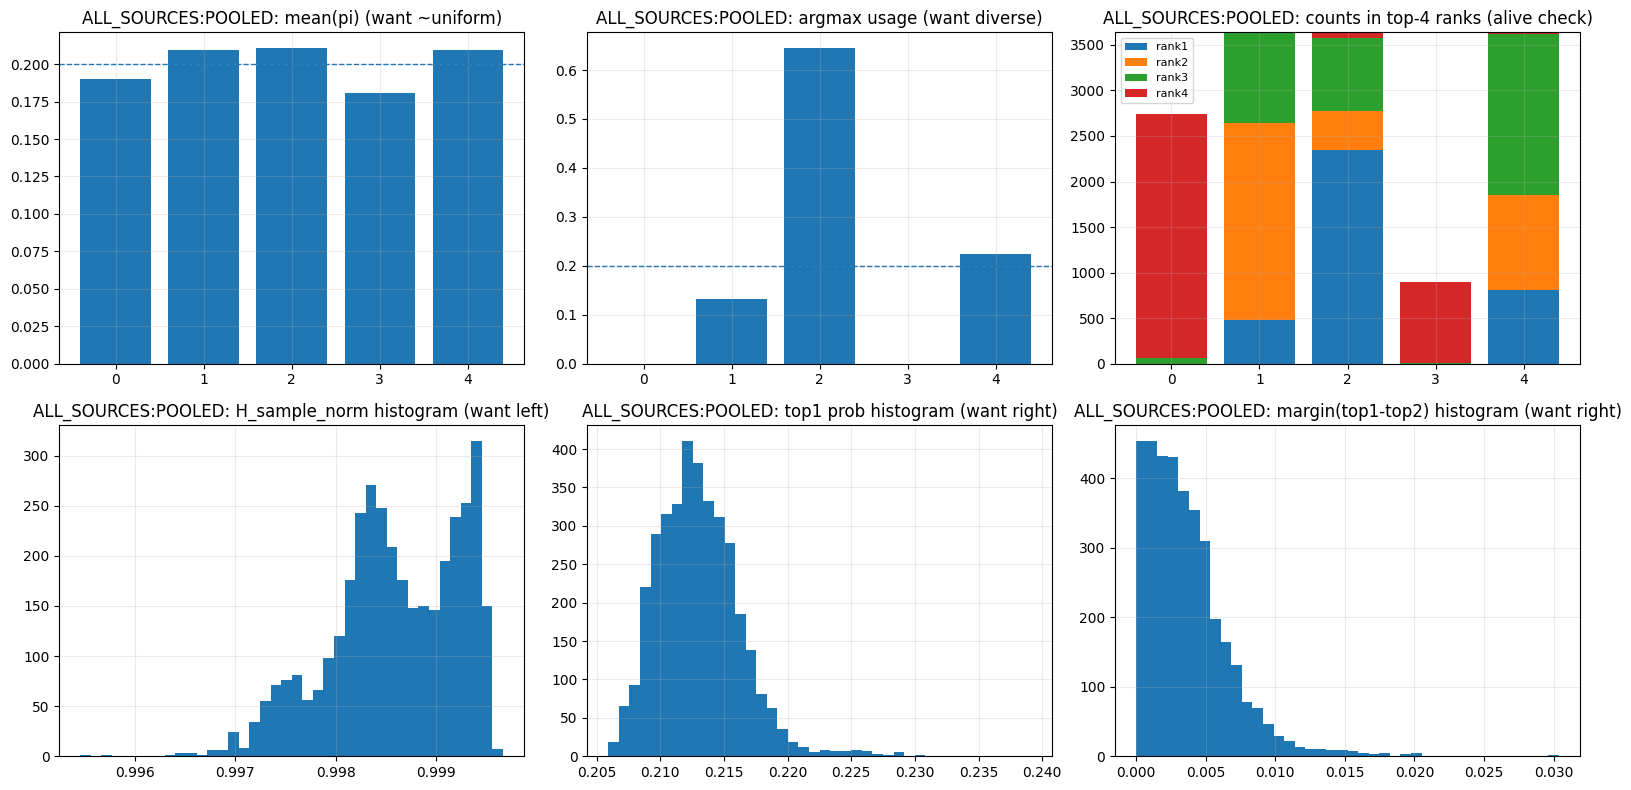


[SRC=Medicaldataset] N=1319, M=5
  H_sample_norm: mean=0.9991  (goal: LOW)
  H_batch_norm : 0.9993            (goal: HIGH)
  top1 prob    : mean=0.2114,  median=0.2105
  margin(top1-top2): mean=0.0037, median=0.0030
  mean(pi) deviation from uniform (L1): 0.0453
  argmax usage deviation from uniform (L1): 0.9040
  top4 coverage: min=0.3920, mean=0.8000, max=1.0000

[SRC=Cardiovascular_Disease_Dataset] N=1000, M=5
  H_sample_norm: mean=0.9983  (goal: LOW)
  H_batch_norm : 0.9983            (goal: HIGH)
  top1 prob    : mean=0.2139,  median=0.2136
  margin(top1-top2): mean=0.0033, median=0.0030
  mean(pi) deviation from uniform (L1): 0.0675
  argmax usage deviation from uniform (L1): 1.0740
  top4 coverage: min=0.0000, mean=0.8000, max=1.0000

[SRC=Heart_disease_statlog] N=270, M=5
  H_sample_norm: mean=0.9989  (goal: LOW)
  H_batch_norm : 0.9990            (goal: HIGH)
  top1 prob    : mean=0.2108,  median=0.2103
  margin(top1-top2): mean=0.0022, median=0.0019
  mean(pi) deviation from

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 1) collect pi (all samples)
# -----------------------------
@torch.no_grad()
def collect_all_pi(model, loaders, device, max_batches_per_src=None):
    model.eval()
    out = {}
    all_pi = []

    for src, loader in loaders.items():
        pis = []
        for bi, batch in enumerate(loader):
            if max_batches_per_src is not None and bi >= max_batches_per_src:
                break
            batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            _ = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi  # [B,M]
            if pi is None:
                raise RuntimeError("last_pi is None. args.use_lcg=True & predict(return_all=True) path 확인")

            pis.append(pi.detach().cpu().numpy())

        if len(pis) == 0:
            continue
        pis = np.concatenate(pis, axis=0)  # [N_src, M]
        out[src] = pis
        all_pi.append(pis)

    all_pi = np.concatenate(all_pi, axis=0) if len(all_pi) else None
    return out, all_pi


# -----------------------------
# 2) diagnostics
# -----------------------------
def _entropy_rows(P, eps=1e-12):
    P = np.clip(P, eps, 1.0)
    return -(P * np.log(P)).sum(axis=1)  # [N]

def _top1_top2(P):
    # returns top1 prob, top2 prob, margin
    part = np.partition(P, -2, axis=1)          # last two are top2 (unordered)
    top2 = part[:, -2]
    top1 = part[:, -1]
    # ensure top1>=top2 (partition doesn't guarantee order between last two)
    t1 = np.maximum(top1, top2)
    t2 = np.minimum(top1, top2)
    return t1, t2, (t1 - t2)

def _rank_hist(P, max_rank=4):
    # counts: for each m, how often it appears in rank r (1..max_rank)
    # rank 1 = argmax
    N, M = P.shape
    order = np.argsort(-P, axis=1)  # descending
    counts = np.zeros((max_rank, M), dtype=np.int64)
    for r in range(max_rank):
        idx_m = order[:, r]
        counts[r] = np.bincount(idx_m, minlength=M)
    return counts  # [max_rank, M]

def diagnose_pi(P, tag="POOLED", show=True):
    P = np.asarray(P)
    N, M = P.shape
    H_max = np.log(M)

    # --- entropies ---
    Hs = _entropy_rows(P)            # [N]
    Hs_norm = Hs / H_max
    pibar = P.mean(axis=0)
    Hb = -(np.clip(pibar, 1e-12, 1.0) * np.log(np.clip(pibar, 1e-12, 1.0))).sum()
    Hb_norm = Hb / H_max

    # --- usage / sharpness proxies ---
    argmax = P.argmax(axis=1)
    usage = np.bincount(argmax, minlength=M) / N  # [M]
    mean_pi = pibar
    t1, t2, margin = _top1_top2(P)

    # --- "dead but alive" check: rank counts ---
    rank_counts = _rank_hist(P, max_rank=4)  # [4, M] ranks 1..4

    # --- prints ---
    print(f"\n[{tag}] N={N}, M={M}")
    print(f"  H_sample_norm: mean={Hs_norm.mean():.4f}  (goal: LOW)")
    print(f"  H_batch_norm : {Hb_norm:.4f}            (goal: HIGH)")
    print(f"  top1 prob    : mean={t1.mean():.4f},  median={np.median(t1):.4f}")
    print(f"  margin(top1-top2): mean={margin.mean():.4f}, median={np.median(margin):.4f}")
    print(f"  mean(pi) deviation from uniform (L1): {np.abs(mean_pi - 1.0/M).sum():.4f}")
    print(f"  argmax usage deviation from uniform (L1): {np.abs(usage - 1.0/M).sum():.4f}")

    # rank-based "alive" quick view
    # 각 m이 rank<=4에 들어오는 비율
    top4_frac = rank_counts.sum(axis=0) / N
    print(f"  top4 coverage: min={top4_frac.min():.4f}, mean={top4_frac.mean():.4f}, max={top4_frac.max():.4f}")

    if not show:
        return

    # ---------------- plots ----------------
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # (1) mean(pi) + argmax usage
    axes[0,0].bar(np.arange(M), mean_pi)
    axes[0,0].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,0].set_title(f"{tag}: mean(pi) (want ~uniform)")
    axes[0,0].grid(True, alpha=0.25)

    axes[0,1].bar(np.arange(M), usage)
    axes[0,1].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,1].set_title(f"{tag}: argmax usage (want diverse)")
    axes[0,1].grid(True, alpha=0.25)

    # (2) rank1~4 counts stacked (dead-but-alive 체크 핵심)
    # rank1=argmax, rank2, rank3, rank4
    bottoms = np.zeros(M, dtype=np.int64)
    labels = ["rank1", "rank2", "rank3", "rank4"]
    for r in range(4):
        axes[0,2].bar(np.arange(M), rank_counts[r], bottom=bottoms, label=labels[r])
        bottoms += rank_counts[r]
    axes[0,2].set_title(f"{tag}: counts in top-4 ranks (alive check)")
    axes[0,2].grid(True, alpha=0.25)
    axes[0,2].legend(fontsize=8, frameon=True)

    # (3) hist: sample entropy
    axes[1,0].hist(Hs_norm, bins=40)
    axes[1,0].set_title(f"{tag}: H_sample_norm histogram (want left)")
    axes[1,0].grid(True, alpha=0.25)

    # (4) hist: top1 prob
    axes[1,1].hist(t1, bins=40)
    axes[1,1].set_title(f"{tag}: top1 prob histogram (want right)")
    axes[1,1].grid(True, alpha=0.25)

    # (5) hist: margin
    axes[1,2].hist(margin, bins=40)
    axes[1,2].set_title(f"{tag}: margin(top1-top2) histogram (want right)")
    axes[1,2].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) run (pooled + per source)
# -----------------------------
pi_by_src, pi_all = collect_all_pi(model, loaders, device, max_batches_per_src=None)

diagnose_pi(pi_all, tag="ALL_SOURCES:POOLED", show=True)

for src, P in pi_by_src.items():
    diagnose_pi(P, tag=f"SRC={src}", show=False)  # source별은 출력만, 그림은 원하면 True로


- H_sample norm histogram (want left)
    - 각 샘플의 entropy H(pi)를 최대 엔트로피 log M으로 나누어 normalize
    - 0에 가까우면 거의 one hot이고 
    - 1에 가까우면 uniform 
    - 현재 막대가 0.98 ~ 1.0 에 몰려 있어서 sample entropy 낮게와는 정반대

- top1 prob histogram (want right)
    - 각 샘플에서 max_m pi_m 가장 큰 값의 분포 
    - flat이면 top 1이 1/M

- top1 - top2 histogram 
    - 각 샘플에서 (1등 확률 - 2등 확률) 차이 
    - 결정의 확신도 
    - 샤프하면 top1이 크고, top2가 작아서 margin이 크게 나옴 
    - 애매하면 top 1 ~ top 2여서 margin이 0 근처 
    - 현재 0 ~ 0.03 근처여서 top1과 top2가 거의 비슷함.


[ALL_SOURCES:POOLED] N=3637, M=5
mu gap(worst-best) = 0.077747  | best m=2, worst m=3
  m2: mu=0.303871  std=0.016018  [min,max]=[0.239242,0.353837]
  m4: mu=0.307151  std=0.021882  [min,max]=[0.211964,0.349544]
  m1: mu=0.307335  std=0.021221  [min,max]=[0.243170,0.350138]
  m0: mu=0.354667  std=0.027688  [min,max]=[0.264333,0.412856]
  m3: mu=0.381619  std=0.038257  [min,max]=[0.280286,0.468254]


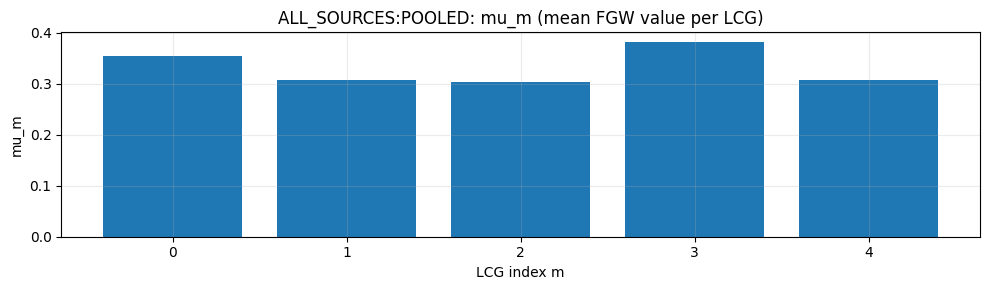

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ot.batch import solve_gromov_batch

@torch.no_grad()
def collect_d_commit(model, loaders_by_src, device, max_batches=None, per_src=False):
    import torch.nn.functional as F
    model.eval()
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')

    def _one_loader(loader):
        d_list = []
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break

            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            name_embeddings, value_embeddings = [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name  = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            B, N, D = value.shape

            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            src_feat = x_basis[:, 1:, :].contiguous()
            var_att = last_att[:, 0, 1:, 1:]
            log_attn = -torch.log(var_att.clamp_min(1e-8))
            with torch.no_grad():
                q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            src_str = (log_attn / q90).clamp_max(1.0)

            lcg_feat, lcg_struct = model.latent_graph()
            M, K, _ = lcg_feat.shape

            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)

            # 수정: cosine M_cost
            if feat_distance == 'cosine':
                src_norm = F.normalize(src_feat_exp, dim=-1)
                tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
                cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
                M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
            else:
                dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
                M_raw = dist_sq / float(D)
                q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
                M_cost = M_raw / q90

            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            alpha = float(model.graph_quantizer.alpha)
            reg   = float(model.graph_quantizer.reg)

            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost,
                alpha=alpha, reg=reg, a=a, b=b,
                max_iter=10, tol=1e-3, grad='envelope'
            )

            d = result.value.reshape(B, M)
            d_list.append(d.detach().cpu().numpy())

        if len(d_list) == 0:
            return None
        return np.concatenate(d_list, axis=0)

    if per_src:
        out = {}
        for src, loader in loaders_by_src.items():
            d = _one_loader(loader)
            if d is not None:
                out[src] = d
        return out
    else:
        all_d = []
        for src, loader in loaders_by_src.items():
            d = _one_loader(loader)
            if d is not None:
                all_d.append(d)
        if len(all_d) == 0:
            return None
        return np.concatenate(all_d, axis=0)


def report_mu_m(d, title="POOLED"):
    """
    d: [N,M]
    """
    d = np.asarray(d)
    mu  = d.mean(axis=0)
    std = d.std(axis=0)
    mn  = d.min(axis=0)
    mx  = d.max(axis=0)

    order = np.argsort(mu)
    best, worst = order[0], order[-1]
    gap = mu[worst] - mu[best]

    print(f"\n[{title}] N={d.shape[0]}, M={d.shape[1]}")
    print(f"mu gap(worst-best) = {gap:.6f}  | best m={best}, worst m={worst}")
    for m in order:
        print(f"  m{m}: mu={mu[m]:.6f}  std={std[m]:.6f}  [min,max]=[{mn[m]:.6f},{mx[m]:.6f}]")

    # 간단 시각화
    plt.figure(figsize=(10,3))
    plt.bar(np.arange(len(mu)), mu)
    plt.title(f"{title}: mu_m (mean FGW value per LCG)")
    plt.xlabel("LCG index m"); plt.ylabel("mu_m")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# =========================
# 사용 예시
# =========================
# 1) 전체 pooled로 확인
d_all = collect_d_commit(model, loaders, device, max_batches=None, per_src=False)
report_mu_m(d_all, title="ALL_SOURCES:POOLED")

# 2) source별로도 보고 싶으면
# d_by_src = collect_d_commit(model, loaders, device, max_batches=50, per_src=True)
# for src, d in d_by_src.items():
#     report_mu_m(d, title=f"SRC={src}")


winner usage: [0.         0.13170195 0.64476217 0.         0.22353588] sum= 1.0
gap stats: mean 0.008821474 median 0.0074201524 p90 0.017362111806869508


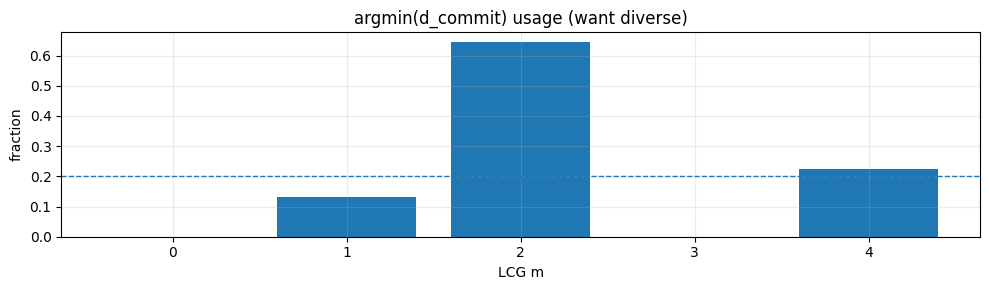

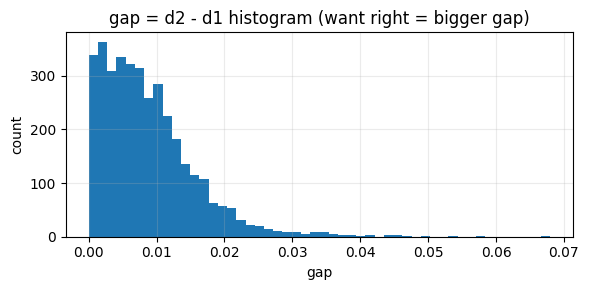

In [30]:
d = d_all

# 1) per-sample best/2nd-best gap (confidence in d-space)
d_sort = np.sort(d, axis=1)         # ascending: smaller is better
gap = d_sort[:, 1] - d_sort[:, 0]   # d2 - d1  (bigger => clearer winner)

# 2) argmin usage (d-space winner diversity)
winner = np.argmin(d, axis=1)
usage = np.bincount(winner, minlength=d.shape[1]) / d.shape[0]

print("winner usage:", usage, "sum=", usage.sum())
print("gap stats: mean", gap.mean(), "median", np.median(gap), "p90", np.quantile(gap, 0.9))

plt.figure(figsize=(10,3))
plt.bar(np.arange(d.shape[1]), usage)
plt.axhline(1.0/d.shape[1], linestyle="--", linewidth=1)
plt.title("argmin(d_commit) usage (want diverse)")
plt.xlabel("LCG m"); plt.ylabel("fraction")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(gap, bins=50)
plt.title("gap = d2 - d1 histogram (want right = bigger gap)")
plt.xlabel("gap"); plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

< 결과 >
- Top 1 과 Top 2의 차이가 거의 없다면 이들의 cost 차이가 없음을 의미 

In [31]:
# init_lcg 직후의 node_embeddings로 centrality 확인
node_emb = model.latent_graph.node_embeddings.data  # [M, K, D]
centroids = node_emb.mean(dim=1)  # [M, D]

# 데이터 전체 centroid (init_lcg에서 수집한 CLS의 평균)와의 거리
data_center = centroids.mean(dim=0)  # [D] — 전체 LCG 중심의 근사
dist_to_center = torch.cdist(centroids.unsqueeze(0), data_center.unsqueeze(0).unsqueeze(0)).squeeze()
print("LCG별 data center까지 거리:")
for m in range(5):
    print(f"  LCG {m}: {dist_to_center[m].item():.4f}")

LCG별 data center까지 거리:
  LCG 0: 7.6530
  LCG 1: 9.3596
  LCG 2: 8.8451
  LCG 3: 12.5963
  LCG 4: 21.6525


In [32]:
# 1. Source별 d_commit 순서 + 2. Node embedding 다양성
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # forward해서 pi 얻기
        _ = model.predict(batch, return_all=True)
        pi = model.graph_quantizer.last_pi  # [B, M]
        
        # d_commit 순서
        argmax_counts = torch.bincount(pi.argmax(1), minlength=5)
        rank_order = pi.mean(0).argsort(descending=True)
        
        print(f"\n=== {src_name} (N nodes = {batch.get('cat_value_embeddings', batch.get('num_prompt_embeddings')).shape[1]}) ===")
        print(f"  mean pi: {pi.mean(0).cpu().numpy().round(4)}")
        print(f"  argmax:  {argmax_counts.cpu().numpy()}")
        print(f"  순서:    {rank_order.cpu().numpy()}")


=== Medicaldataset (N nodes = 1) ===
  mean pi: [0.1904 0.2082 0.2087 0.1853 0.2074]
  argmax:  [ 0  6 20  0  6]
  순서:    [2 1 4 0 3]

=== Cardiovascular_Disease_Dataset (N nodes = 5) ===
  mean pi: [0.1906 0.2104 0.2111 0.1773 0.2106]
  argmax:  [ 0  3 18  0 11]
  순서:    [2 4 1 0 3]

=== Heart_disease_statlog (N nodes = 6) ===
  mean pi: [0.1931 0.2084 0.2088 0.1807 0.209 ]
  argmax:  [ 0  3 18  0 11]
  순서:    [4 2 1 0 3]

=== Erbil_Cardiovascular_Health_Dataset (N nodes = 12) ===
  mean pi: [0.1905 0.2119 0.2159 0.1688 0.2129]
  argmax:  [ 0  0 24  0  8]
  순서:    [2 4 1 0 3]

=== cardio_SAheart (N nodes = 1) ===
  mean pi: [0.1884 0.2084 0.2139 0.1782 0.2111]
  argmax:  [ 0  0 24  0  8]
  순서:    [2 4 1 0 3]

=== heart_failure_clinical_records (N nodes = 5) ===
  mean pi: [0.193  0.2102 0.2098 0.1778 0.2092]
  argmax:  [ 0 16 11  0  5]
  순서:    [1 2 4 0 3]


In [33]:
# 각 LCG의 CT와 각 source의 CS 간 구조적 유사도
import torch

model.eval()
with torch.no_grad():
    # LCG의 CT (target structure)
    if model.latent_graph.struct_mode == 'static':
        CT = 1.0 - torch.sigmoid(model.latent_graph.adj_param.data)  # [M, K, K]
    
    print("=== CT 통계 ===")
    for m in range(5):
        ct = CT[m]
        print(f"  LCG {m}: mean={ct.mean():.4f}, std={ct.std():.4f}, "
              f"diag_mean={ct.diag().mean():.4f}, offdiag_mean={ct[~torch.eye(ct.size(0),dtype=bool)].mean():.4f}")
    
    # LCG 간 CT 유사도
    print("\n=== LCG 간 CT 유사도 (Frobenius) ===")
    for i in range(5):
        for j in range(i+1, 5):
            diff = (CT[i] - CT[j]).norm()
            print(f"  LCG {i} vs {j}: {diff.item():.4f}")
    
    # LCG 7 vs 나머지의 평균 차이
    print("\n=== LCG 7 vs 나머지 ===")
    for m in range(5):
        if m == 7: continue
        diff = (CT[4] - CT[m]).norm()
        print(f"  LCG 7 vs {m}: {diff.item():.4f}")

=== CT 통계 ===
  LCG 0: mean=0.3768, std=0.3422, diag_mean=0.0105, offdiag_mean=0.4291
  LCG 1: mean=0.4503, std=0.3111, diag_mean=0.0111, offdiag_mean=0.5130
  LCG 2: mean=0.5557, std=0.3379, diag_mean=0.0092, offdiag_mean=0.6338
  LCG 3: mean=0.3566, std=0.3579, diag_mean=0.0097, offdiag_mean=0.4061
  LCG 4: mean=0.4807, std=0.3400, diag_mean=0.0108, offdiag_mean=0.5479

=== LCG 간 CT 유사도 (Frobenius) ===
  LCG 0 vs 1: 3.3478
  LCG 0 vs 2: 3.3295
  LCG 0 vs 3: 3.4459
  LCG 0 vs 4: 2.7528
  LCG 1 vs 2: 3.0123
  LCG 1 vs 3: 3.5914
  LCG 1 vs 4: 3.1108
  LCG 2 vs 3: 3.7511
  LCG 2 vs 4: 2.8830
  LCG 3 vs 4: 4.1083

=== LCG 7 vs 나머지 ===
  LCG 7 vs 0: 2.7528
  LCG 7 vs 1: 3.1108
  LCG 7 vs 2: 2.8830
  LCG 7 vs 3: 4.1083
  LCG 7 vs 4: 0.0000


In [34]:
# 이미 data_pool이 있으니까 바로 hierarchical 시뮬레이션
from sklearn.cluster import KMeans
# data_pool 재구성: 모든 source의 node embeddings 수집
model.eval()
data_pool_list = []
with torch.no_grad():
    for src, loader in loaders.items():
        for batch in loader:
            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
            
            name_embs, val_embs = [], []
            if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
            if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
            if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
            if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
            name = torch.cat(name_embs, dim=1)
            val = torch.cat(val_embs, dim=1)
            x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x)
                out, _ = model.basis_layers[l](name, norm_x)
                x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
            
            node_emb = x[:, 1:, :].cpu().numpy()  # [B, N, D]
            for b in range(node_emb.shape[0]):
                data_pool_list.append(node_emb[b])  # [N, D]

data_pool = np.concatenate(data_pool_list, axis=0)  # [total_nodes, D]
print(f"data_pool shape: {data_pool.shape}")
M, K = 5, 8
km_global = KMeans(n_clusters=M, n_init=10, random_state=args.random_seed).fit(data_pool)

centroids_hier = np.zeros((M, K, 768))
for m in range(M):
    group = data_pool[km_global.labels_ == m]
    print(f"LCG {m}: {len(group)} samples")
    km_local = KMeans(n_clusters=K, n_init=10, random_state=args.random_seed).fit(group)
    centroids_hier[m] = km_local.cluster_centers_

# CT std 비교
centroids_t = torch.tensor(centroids_hier, dtype=torch.float32)
dist = torch.cdist(centroids_t, centroids_t, p=2) ** 2
for m in range(M):
    q90 = torch.quantile(dist[m].flatten(), 0.9).clamp_min(1e-8)
    d = (dist[m] / q90).clamp_max(1.0)
    ct = 1.0 - d
    # data center 거리도
    group_center = centroids_hier[m].mean(axis=0)
    dc = np.linalg.norm(group_center - data_pool.mean(axis=0))
    print(f"  LCG {m}: CT mean={ct.mean():.4f}, std={ct.std():.4f}, data_center_dist={dc:.4f}")

data_pool shape: (41010, 768)
LCG 0: 3193 samples
LCG 1: 8158 samples
LCG 2: 10880 samples
LCG 3: 2263 samples
LCG 4: 16516 samples
  LCG 0: CT mean=0.7803, std=0.3566, data_center_dist=456.6284
  LCG 1: CT mean=0.6174, std=0.3307, data_center_dist=125.3591
  LCG 2: CT mean=0.6174, std=0.3522, data_center_dist=105.8711
  LCG 3: CT mean=0.7794, std=0.3656, data_center_dist=341.4733
  LCG 4: CT mean=0.6488, std=0.3273, data_center_dist=18.8833


In [35]:
# Round robin 시뮬레이션
kmeans_rr = KMeans(n_clusters=M*K, n_init=10, random_state=args.random_seed).fit(data_pool)
centers_rr = torch.tensor(kmeans_rr.cluster_centers_, dtype=torch.float32)
rr_centroids = centers_rr.view(K, M, 768).transpose(0, 1).contiguous()

# 모델에 round robin 적용
model.latent_graph.node_embeddings.data.copy_(rr_centroids.to(device))

# adj_param도 초기화
dist = torch.cdist(rr_centroids.to(device), rr_centroids.to(device), p=2) ** 2
for m in range(M):
    q90 = torch.quantile(dist[m].flatten(), 0.9).clamp_min(1e-8)
    dist[m] = (dist[m] / q90).clamp_max(1.0)
target = (1.0 - dist).clamp(0.01, 0.99)
adj_init = torch.log(target / (1.0 - target))
model.latent_graph.adj_param.data.copy_(adj_init.to(device))

# Source별 확인
args.use_lcg = True
model.eval()
with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        _ = model.predict(batch, return_all=True)
        pi = model.graph_quantizer.last_pi
        margin = (pi.topk(2, dim=1)[0][:, 0] - pi.topk(2, dim=1)[0][:, 1]).mean()
        print(f"{src_name}:")
        print(f"  mean pi: {pi.mean(0).cpu().numpy().round(4)}")
        print(f"  argmax:  {torch.bincount(pi.argmax(1), minlength=8).cpu().numpy()}")
        print(f"  margin:  {margin.item():.4f}")

Medicaldataset:
  mean pi: [0.1827 0.1995 0.2065 0.2056 0.2057]
  argmax:  [ 0  2 16  5  9  0  0  0]
  margin:  0.0072
Cardiovascular_Disease_Dataset:
  mean pi: [0.1801 0.2031 0.2015 0.2077 0.2077]
  argmax:  [ 0  5  9  8 10  0  0  0]
  margin:  0.0032
Heart_disease_statlog:
  mean pi: [0.1809 0.2042 0.1963 0.2089 0.2098]
  argmax:  [ 0  6  5  5 16  0  0  0]
  margin:  0.0029
Erbil_Cardiovascular_Health_Dataset:
  mean pi: [0.1774 0.2073 0.1869 0.2128 0.2156]
  argmax:  [ 0  0  0  4 28  0  0  0]
  margin:  0.0039
cardio_SAheart:
  mean pi: [0.1802 0.2001 0.2052 0.2073 0.2072]
  argmax:  [ 0  4 13 11  4  0  0  0]
  margin:  0.0069
heart_failure_clinical_records:
  mean pi: [0.1791 0.2065 0.1931 0.2102 0.2111]
  argmax:  [ 0  7  4  5 16  0  0  0]
  margin:  0.0027


In [36]:
model.eval()
with torch.no_grad():
    batch = next(iter(list(loaders.values())[0]))
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    
    name_embs, val_embs = [], []
    if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
    if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
    if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
    if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
    name = torch.cat(name_embs, dim=1)
    val = torch.cat(val_embs, dim=1)
    x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x)
        out, _ = model.basis_layers[l](name, norm_x)
        x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
    
    src_feat = x[:, 1:, :]
    M = model.latent_graph.M
    lcg_feat = model.latent_graph.node_embeddings.data
    
    s = F.normalize(src_feat[0:1].expand(M, -1, -1), dim=-1)
    t = F.normalize(lcg_feat, dim=-1)
    
    cos_sim = torch.bmm(s, t.transpose(1, 2))
    
    m1 = 1.0 - torch.exp(-(1.0 - cos_sim))
    m2 = 1.0 - cos_sim
    m3 = (1.0 - cos_sim) ** 2
    
    print("=== M_cost per LCG (sample 0) ===")
    print(f"1-exp:  mean per LCG = {m1.mean(dim=(1,2)).cpu().numpy().round(4)}")
    print(f"        range = {(m1.mean(dim=(1,2)).max() - m1.mean(dim=(1,2)).min()).item():.6f}")
    print()
    print(f"1-cos:  mean per LCG = {m2.mean(dim=(1,2)).cpu().numpy().round(4)}")
    print(f"        range = {(m2.mean(dim=(1,2)).max() - m2.mean(dim=(1,2)).min()).item():.6f}")
    print()
    print(f"(1-cos)^2: mean per LCG = {m3.mean(dim=(1,2)).cpu().numpy().round(4)}")
    print(f"           range = {(m3.mean(dim=(1,2)).max() - m3.mean(dim=(1,2)).min()).item():.6f}")

=== M_cost per LCG (sample 0) ===
1-exp:  mean per LCG = [0.448  0.4324 0.4979 0.3969 0.3999]
        range = 0.101057

1-cos:  mean per LCG = [0.9994 0.8689 1.1208 0.8808 0.8793]
        range = 0.251891

(1-cos)^2: mean per LCG = [1.9243 1.4691 2.1765 1.6899 1.6688]
           range = 0.707414


In [37]:
model.eval()
with torch.no_grad():
    M = model.latent_graph.M
    lcg_feat = model.latent_graph.node_embeddings.data
    t = F.normalize(lcg_feat, dim=-1)
    
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        name_embs, val_embs = [], []
        if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
        if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
        if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
        if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        name = torch.cat(name_embs, dim=1)
        val = torch.cat(val_embs, dim=1)
        x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x)
            out, _ = model.basis_layers[l](name, norm_x)
            x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
        
        src_feat = x[:, 1:, :]
        s = F.normalize(src_feat[0:1].expand(M, -1, -1), dim=-1)
        cos_sim = torch.bmm(s, t.transpose(1, 2))
        
        m1 = 1.0 - torch.exp(-(1.0 - cos_sim))
        m2 = 1.0 - cos_sim
        m3 = (1.0 - cos_sim) ** 2
        
        r1 = (m1.mean(dim=(1,2)).max() - m1.mean(dim=(1,2)).min()).item()
        r2 = (m2.mean(dim=(1,2)).max() - m2.mean(dim=(1,2)).min()).item()
        r3 = (m3.mean(dim=(1,2)).max() - m3.mean(dim=(1,2)).min()).item()
        
        # 각 방법별 1등 LCG
        best1 = m1.mean(dim=(1,2)).argmin().item()
        best2 = m2.mean(dim=(1,2)).argmin().item()
        best3 = m3.mean(dim=(1,2)).argmin().item()
        
        print(f"\n=== {src_name} (N={src_feat.shape[1]}) ===")
        print(f"  1-exp:    range={r1:.6f}  best=LCG{best1}  vals={m1.mean(dim=(1,2)).cpu().numpy().round(4)}")
        print(f"  1-cos:    range={r2:.6f}  best=LCG{best2}  vals={m2.mean(dim=(1,2)).cpu().numpy().round(4)}")
        print(f"  (1-cos)²: range={r3:.6f}  best=LCG{best3}  vals={m3.mean(dim=(1,2)).cpu().numpy().round(4)}")


=== Medicaldataset (N=8) ===
  1-exp:    range=0.101057  best=LCG3  vals=[0.448  0.4324 0.4979 0.3969 0.3999]
  1-cos:    range=0.251891  best=LCG1  vals=[0.9994 0.8689 1.1208 0.8808 0.8793]
  (1-cos)²: range=0.707414  best=LCG1  vals=[1.9243 1.4691 2.1765 1.6899 1.6688]

=== Cardiovascular_Disease_Dataset (N=13) ===
  1-exp:    range=0.111298  best=LCG3  vals=[0.444  0.3994 0.4971 0.3858 0.3932]
  1-cos:    range=0.310118  best=LCG1  vals=[1.0013 0.8179 1.128  0.8613 0.8722]
  (1-cos)²: range=0.805498  best=LCG1  vals=[1.9516 1.4027 2.2082 1.6577 1.6721]

=== Heart_disease_statlog (N=13) ===
  1-exp:    range=0.042242  best=LCG3  vals=[0.4471 0.4614 0.4674 0.4252 0.4275]
  1-cos:    range=0.111846  best=LCG1  vals=[0.999  0.94   1.0519 0.947  0.9459]
  (1-cos)²: range=0.423584  best=LCG1  vals=[1.9255 1.6174 2.041  1.8211 1.8056]

=== Erbil_Cardiovascular_Health_Dataset (N=20) ===
  1-exp:    range=0.144770  best=LCG1  vals=[0.4718 0.3881 0.5329 0.4049 0.4114]
  1-cos:    range=0.383

In [38]:
import torch.nn.functional as F_func

model.eval()
with torch.no_grad():
    M = model.latent_graph.M
    lcg_feat = model.latent_graph.node_embeddings.data
    t = F.normalize(lcg_feat, dim=-1)
    
    def znorm(d):
        return (d - d.mean(dim=1, keepdim=True)) / d.std(dim=1, keepdim=True).clamp_min(1e-8)
    
    print("=== Pi simulation (softmax over mean M_cost) ===")
    for tau in [0.1, 0.5, 1.0]:
        print(f"\n--- tau = {tau} ---")
        for src_name, loader in loaders.items():
            batch = next(iter(loader))
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            name_embs, val_embs = [], []
            if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
            if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
            if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
            if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
            name = torch.cat(name_embs, dim=1)
            val = torch.cat(val_embs, dim=1)
            x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x)
                out, _ = model.basis_layers[l](name, norm_x)
                x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
            
            src_feat = x[:, 1:, :]
            s = F.normalize(src_feat[0:1].expand(M, -1, -1), dim=-1)
            cos_sim = torch.bmm(s, t.transpose(1, 2))
            
            m1 = 1.0 - torch.exp(-(1.0 - cos_sim))
            m2 = 1.0 - cos_sim
            m3 = (1.0 - cos_sim) ** 2
            
            d1 = m1.mean(dim=(1,2)).unsqueeze(0)
            d2 = m2.mean(dim=(1,2)).unsqueeze(0)
            d3 = m3.mean(dim=(1,2)).unsqueeze(0)
            
            pi1 = F_func.softmax(-d1 / tau, dim=1).squeeze().cpu().numpy().round(3)
            pi2 = F_func.softmax(-d2 / tau, dim=1).squeeze().cpu().numpy().round(3)
            pi3 = F_func.softmax(-d3 / tau, dim=1).squeeze().cpu().numpy().round(3)
            pi1z = F_func.softmax(-znorm(d1) / tau, dim=1).squeeze().cpu().numpy().round(3)
            pi3z = F_func.softmax(-znorm(d3) / tau, dim=1).squeeze().cpu().numpy().round(3)
            
            print(f"  {src_name:45s} 1-exp: {pi1}  (1-cos)²: {pi3}  znorm+1-exp: {pi1z}  znorm+(1-cos)²: {pi3z}")

=== Pi simulation (softmax over mean M_cost) ===

--- tau = 0.1 ---
  Medicaldataset                                1-exp: [0.165 0.193 0.1   0.275 0.267]  (1-cos)²: [0.008 0.795 0.001 0.087 0.108]  znorm+1-exp: [0.    0.    0.    0.677 0.323]  znorm+(1-cos)²: [0.    0.999 0.    0.    0.001]
  Cardiovascular_Disease_Dataset                1-exp: [0.152 0.237 0.089 0.271 0.252]  (1-cos)²: [0.004 0.87  0.    0.068 0.059]  znorm+1-exp: [0.    0.044 0.    0.792 0.164]  znorm+(1-cos)²: [0. 1. 0. 0. 0.]
  Heart_disease_statlog                         1-exp: [0.194 0.169 0.159 0.242 0.236]  (1-cos)²: [0.034 0.745 0.011 0.097 0.113]  znorm+1-exp: [0.    0.    0.    0.774 0.226]  znorm+(1-cos)²: [0. 1. 0. 0. 0.]
  Erbil_Cardiovascular_Health_Dataset           1-exp: [0.131 0.302 0.071 0.256 0.24 ]  (1-cos)²: [0.002 0.872 0.    0.075 0.05 ]  znorm+1-exp: [0.    0.925 0.    0.056 0.019]  znorm+(1-cos)²: [0.    0.999 0.    0.001 0.   ]
  cardio_SAheart                                1-exp: [0.23  

In [39]:
lcg_feat, lcg_struct = model.latent_graph()
print(f"CT range: [{lcg_struct.min():.4f}, {lcg_struct.max():.4f}]")
print(f"CT mean: {lcg_struct.mean():.4f}")

# src_str도 확인
model.eval()
with torch.no_grad():
    batch = next(iter(list(loaders.values())[0]))
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
    _ = model.predict(batch, return_all=True)
    src_str = model._last_P_basis
    print(f"CS range: [{src_str.min():.4f}, {src_str.max():.4f}]")
    print(f"CS mean: {src_str.mean():.4f}")

CT range: [0.0100, 0.9900]
CT mean: 0.2951
CS range: [0.1887, 1.0000]
CS mean: 0.7085
